# Assignment 1
## Statistical distributions in R
STA 5206, Fall 2026

Name: Lucy Ha

Complete all five questions. Include your code, plots, and written answers in this notebook. Label plot axes and report units with your estimates. Support each model choice with the results you obtain. Use `=` for assignment in R.

Before submitting, restart the R kernel and run the notebook from top to bottom. Save the notebook with its output visible.


## Getting started

Keep the `data` folder in the same directory as this notebook. Run the following cell from that directory. The first two files contain synthetic observations. The remaining files contain real data from R's datasets package. Descriptions and sources are in [data/README.md](data/README.md).

You may use `MASS::fitdistr` for maximum likelihood estimation. Write your calculations and plots in the answer cells.

For a fitted model, calculate AIC as $2k - 2\ell$, where $k$ is the number of estimated parameters and $\ell$ is the maximized log likelihood. Compare AIC values only for models fitted to the same observations on the same measurement scale.

When asked for a KS distance, sort the observations as $x_{(1)},\ldots,x_{(n)}$ and calculate
$$D = \max_{1\leq i\leq n}\left\{\frac{i}{n}-F(x_{(i)}),\ F(x_{(i)})-\frac{i-1}{n}\right\}.$$
Use this as a descriptive measure of fit. The usual KS test p value is not valid when the model parameters were estimated from the same sample.


In [2]:
library(MASS)
inspection = read.csv("data/inspection.csv")
service = read.csv("data/service_times.csv")
geyser = read.csv("data/faithful.csv")
air = read.csv("data/airquality.csv", na.strings = "NA")
sprays = read.csv("data/insect_sprays.csv")
rainfall = read.csv("data/precipitation.csv")
flowers = read.csv("data/iris.csv")


## Question 1
### Daily inspections

A manufacturer checks 50 items each day. The file `inspection.csv` records the number of defective items in each sample. These observations are synthetic.


**(a)** Summarize the defect counts. Estimate the probability that an inspected item is defective. State the assumptions needed for a Binomial model and explain what its two parameters represent.


In [109]:
#Extracting defects column from inspection data frame
x <- inspection$defects
#Get descriptive statistics for defects
summary(x)
mean(x)
var(x)
sd(x)
#Estimate the proportion of defects in the population
pHat <- mean(x)/50
pHat
#Final estimate of the proportion of defects in the population
sum(inspection$defects)/sum(inspection$inspected)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    3.00    4.00    3.97    5.00    9.00 

[1] 3.97

[1] 3.847576

[1] 1.961524

[1] 0.0794

[1] 0.0794

There are 100 daily observations in the dataset with 50 items inspected each day. As shown, the number of defects per day ranges from 0 to 9 with a mean of 3.97 defects, a median of 4 defects, and a variance of approximately 3.848, and a standard deviation approximately 1.962. Since each day consisted of 50 items inspected and each item can be classified as defective vs. non-defective, a Binomial model is the reasonable method here. As calculated, the estimated probability that an item is defective is 0.0794. This means approximately 7.94% of inspected items are estimated to be defective giving the fitted model of $X \sim \operatorname{Binomial}(50, 0.0794)$. 


**(b)** Fit a Binomial model to the daily counts. Plot observed and expected frequencies, then estimate the probability of finding at least 7 defective items in a day.


In [110]:
#Include values from last part
x <- inspection$defects
pHat <- mean(x)/50
n <- 50
#Observe the number of defects in the sample
table(x)
#Observe and expected frequencies for defects from 0 to 9
k <- 0:9
observed <- as.numeric(table(factor(x, levels = k)))
expected <- length(x) * dbinom(k, size = n, prob = pHat)
data.frame(Defects = k, Observed = observed, Expected = expected)
#Calculate the probability of observing 7 or more defects in a sample of 50 items
prob7OrMore <- 1 - pbinom(6, size = n, prob = pHat)
prob7OrMore
mean(x >= 7)

x
 0  1  2  3  4  5  6  7  8  9 
 2  5 17 22 17 18  7  6  4  2 

Defects,Observed,Expected
<int>,<dbl>,<dbl>
0,2,1.597896
1,5,6.890775
2,17,14.560748
3,22,20.093389
4,17,20.362945
5,18,16.157641
6,7,10.451744
7,6,5.666213
8,4,2.626763


[1] 0.09884862

[1] 0.12

Using the fitted model $X \sim \operatorname{Binomial}(50, 0.0794)$, I calculated the expected frequency of each daily defect count by multiplying its Binomial probability by the 100 observed days. The expected frequencies are reasonably similar to the observed frequencies. For example, the model predicts approximately 20.363 days with 4 defects, compared with 17 days observed, and approximately 5.666 days with 7 defects, compared with 6 days observed. The probability of observing at least 7 defective items in a day is $\begin{aligned} P(X \geq 7) &= 1 - P(X \leq 6) \\ &= 1 - \operatorname{pbinom}(6; 50, 0.0794) \approx 0.09885.\end{aligned}$. Therefore, under the fitted Binomial model, there is approximately a 9.885% chance that at least 7 of the 50 inspected items will be defective on a given day. In the observed data, 12 of the 100 days had at least 7 defects, corresponding to an empirical proportion of 12%.


**(c)** Fit a Poisson model to the same counts. Compare its AIC with the Binomial AIC. Compare the sample mean and variance, and plot observed and Poisson expected frequencies.


[1] 3.97

[1] 3.97

[1] 3.847576

[1] 0.9691627

Defects,Observed,Expected
<int>,<dbl>,<dbl>
0,2,1.887343
1,5,7.492753
2,17,14.873115
3,22,19.682088
4,17,19.534473
5,18,15.510371
6,7,10.262696
7,6,5.820415
8,4,2.888381


[1] 414.5233

[1] 414.5268

[1] 0.003553924

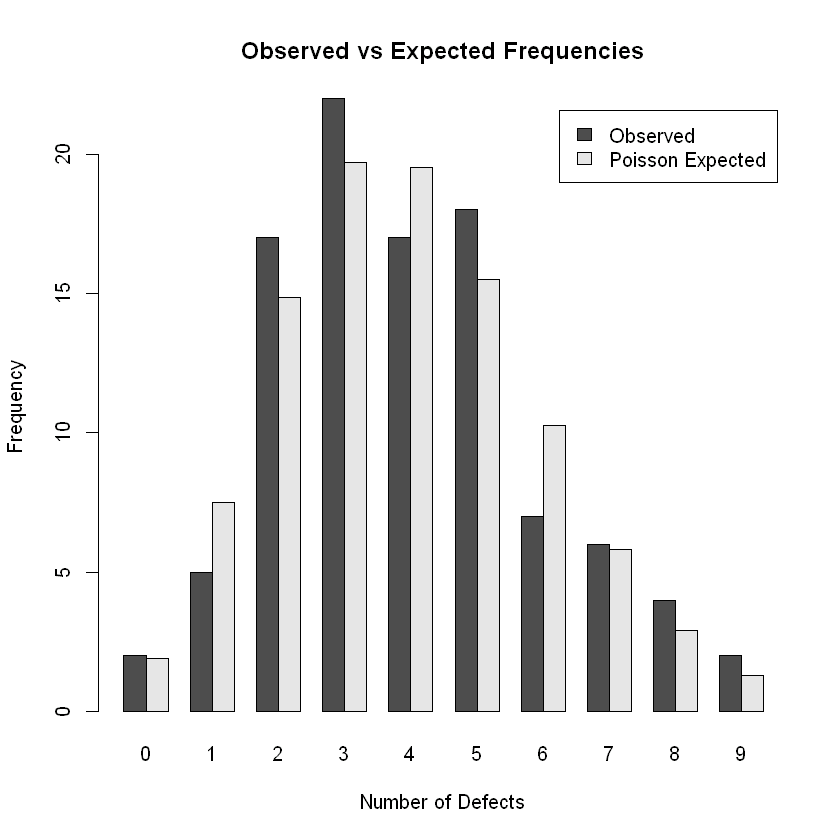

In [111]:

#Include values already calculated
x <- inspection$defects
n <- 50
pHat <- mean(x) / n
#Fit the Poisson model to the data and estimate the parameter lambda
lambdaHat <- mean(x)
lambdaHat
#Compare the sample mean and variance to the Poisson model
sampleMean <- mean(x)
sampleVariance <- var(x)
sampleMean
sampleVariance
sampleVariance / sampleMean
#Observe and expected Poisson frequencies for defects from 0 to 9
k <- 0:9
poissonObserved <- as.numeric(table(factor(x, levels = k)))
poissonExpected <- length(x) * dpois(k, lambda = lambdaHat)
#Create a data frame to display the observed and expected frequencies for the Poisson model
poissonTable <- data.frame(
    Defects = k,
    Observed = poissonObserved,
    Expected = poissonExpected
)
poissonTable
#Create a bar plot to compare the observed and expected frequencies for the Poisson model
barplot(
    rbind(poissonTable$Observed, poissonTable$Expected),
    beside = TRUE,
    names.arg = poissonTable$Defects,
    xlab = "Number of Defects",
    ylab = "Frequency",
    main = "Observed vs Expected Frequencies",
    legend = c("Observed", "Poisson Expected")
)
#Calculate the log-likelihood and AIC for the Poisson and Binomial models
logLikelyhoodPoisson <- sum(
    dpois(x, lambda = lambdaHat, log = TRUE)
)
aicPoisson <- -2 * logLikelyhoodPoisson + 2
logLikelyhoodBinomial <- sum(
    dbinom(x, size = n, prob = pHat, log = TRUE)
)
aicBinomial <- -2 * logLikelyhoodBinomial + 2
aicPoisson
aicBinomial
aicBinomial - aicPoisson

As shown above, I fitted a Poisson distribution to the daily defect counts using the sample mean as the maximum-likelihood estimate of the Poisson rate parameter. Since the sample mean is 3.97, the fitted model is $X \sim \operatorname{Poisson}(3.97)$. The sample mean is 3.97 and the sample variance is approximately 3.848. These values are very similar, with a variance-to-mean ratio of approximately 0.969. This is consistent with the Poisson assumption that the mean and variance are both equal to $\lambda$. The observed and Poisson expected frequencies also reveal a similar pattern. The Poisson model has an AIC of approximately 414.523, while the fitted Binomial model has an AIC of approximately 414.527. Although the Poisson model has a slightly smaller AIC, the difference is only about 0.004, so the two models provide essentially equivalent fits according to AIC. This similarity is also reasonable because the fitted Binomial model has n = 50, p = 0.0794, and np = 3.97, which are all conditions under which a Poisson distribution can closely approximate a Binomial distribution. 

The observed and Poisson expected frequencies in the barplot follow a similar overall pattern. Both distributions are concentrated around approximately 2–6 defects per day and decrease toward the larger defect counts. The expected frequencies are reasonably close to the observed frequencies, although some differences are visible. For example, the Poisson model underestimates the observed frequency at 3 and 5 defects and overestimates the frequency at 4 and 6 defects. Overall, however, the Poisson model captures the general shape of the observed defect-count distribution reasonably well. This is consistent with the sample mean of 3.97 being close to the sample variance of approximately 3.848, as expected under a Poisson model. Lastly, the Poisson AIC is nearly identical to the Binomial AIC, providing little evidence of a substantial difference in fit between the two models.


**(d)** Make a Normal QQ plot of the counts. Estimate the probability of at least 7 defects using a Normal approximation to the fitted Binomial model with a continuity correction. Construct a 95% t confidence interval for the mean daily defect proportion.


[1] 3.97

[1] 3.654782

[1] 1.911748

[1] 0.09285188

[1] 0.0794


	One Sample t-test

data:  dailyProp
t = 20.239, df = 99, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 0.07161582 0.08718418
sample estimates:
mean of x 
   0.0794 


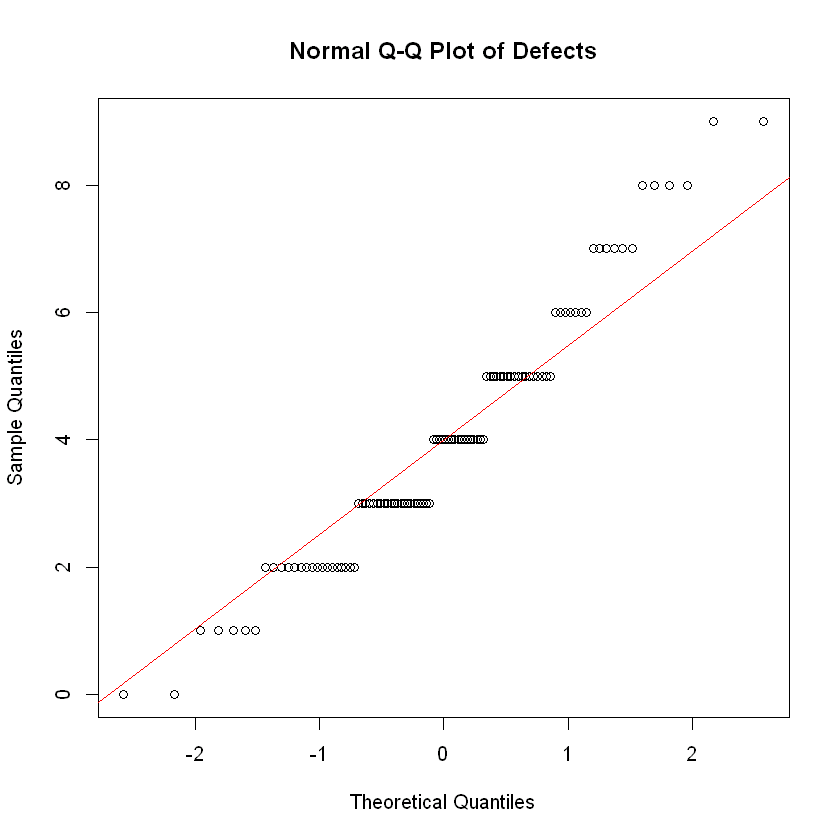

In [112]:
#Include values already calculated once more
x <- inspection$defects
n <- 50
pHat <- mean(x) / n
#Find out if the points in the Q-Q plot are close to the line, which would indicate that the data is approximately normally distributed
qqnorm(x, main = "Normal Q-Q Plot of Defects")
qqline(x, col = "red")
#Calculate the mean, variance, and standard deviation of the normal distribution that approximates the binomial distribution
normalMean <- n * pHat
normalVariance <- n * pHat * (1 - pHat)
normalSD <- sqrt(normalVariance)
normalMean
normalVariance
normalSD
#Calculate the probability of observing 7 or more defects in a sample of 50 items using the normal approximation to the binomial distribution
normalProb7OrMore <- 1 - pnorm(6.5, mean = normalMean, sd = normalSD)
normalProb7OrMore
#Calculate the daily proportion of defects and the mean of the daily proportions
dailyProp <- inspection$defects / inspection$inspected
mean(dailyProp)
#Calculate the 95% confidence interval for the mean of the daily proportions using a t-test
t.test(dailyProp, conf.level = 0.95)

As we used the fitted Binomial model from 1(a), the corresponding Normal approximation has mean $\mu = np = 50(0.0794) = 3.97$ and variance $\sigma^2 = np(1-p) = 50(0.0794)(1-0.0794)\approx 3.6548$. Which gives a standard deviation of approximately 1.912. To approximate the probability of at least 7 defects, I used a continuity correction from 7 to 6.5. This gives $P(X \geq 7)\approx P(Y > 6.5)\approx 0.0929$. This is reasonably close to the exact Binomial probability of approximately 9.885% obtained in 1(b). 

The mean daily defect proportion is 0.0794. A 95% t confidence interval for the mean daily defect proportion is approximately (0.0716, 0.0872). Therefore, the mean daily proportion of defective items is estimated to lie between 7.16% and 8.72% with 95% confidence. 


**(e)** Choose a model for daily reporting. Use your estimates to explain what the manufacturer can expect and identify a limitation of your choice.


I would use Binomial model for daily reporting since the manufacturer inspects a fixed number of 50 items per day and each item was classified as either defective or non-defective. Based on the observed data, the estimated probability that an individual item is defective is 0.0794, giving us the fitted model of $X \sim \operatorname{Binomial}(50, 0.0794)$. From here, the manufacturer can expect an average of 50(0.0794) = 3.97, which is close to 4 defective items per daily sample of 50. The estimated probability of observing at least 7 defects on a given day is approximiately 0.09885, or 9.885%. As for the 95% confidence interval interval from 1(d) produced a similar probability for at least 7 defects, the binomial model seems more appropriate for daily reporting because the defect count is so discrete and Binomial distribution directly represents the fixed number of defective vs. non-defective trials. One limitation of the binomial model would be that the individual defect outcomes are independent and that the probability of a defect remains approximately constant. If production conditions change over time or defects occur in related clusters, these assumptions may not hold.


## Question 2
### Service times

The synthetic observations in `service_times.csv` are service durations in minutes, listed in the order they occurred. Investigate whether one distribution describes the entire record. Preserve the observation order when dividing the data.


**(a)** Make a plot of service time against observation order, a histogram with a density estimate, and a box plot. Describe the distribution and any evidence of a change over time.


,order,service_minutes
,<int>,<dbl>
1,1,4.56
2,2,11.30
3,3,0.68
4,4,9.53
5,5,3.08
6,6,14.13


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.68    5.81   11.09   11.57   15.88   38.45 

[1] 11.57383

[1] 45.43558

[1] 6.740592

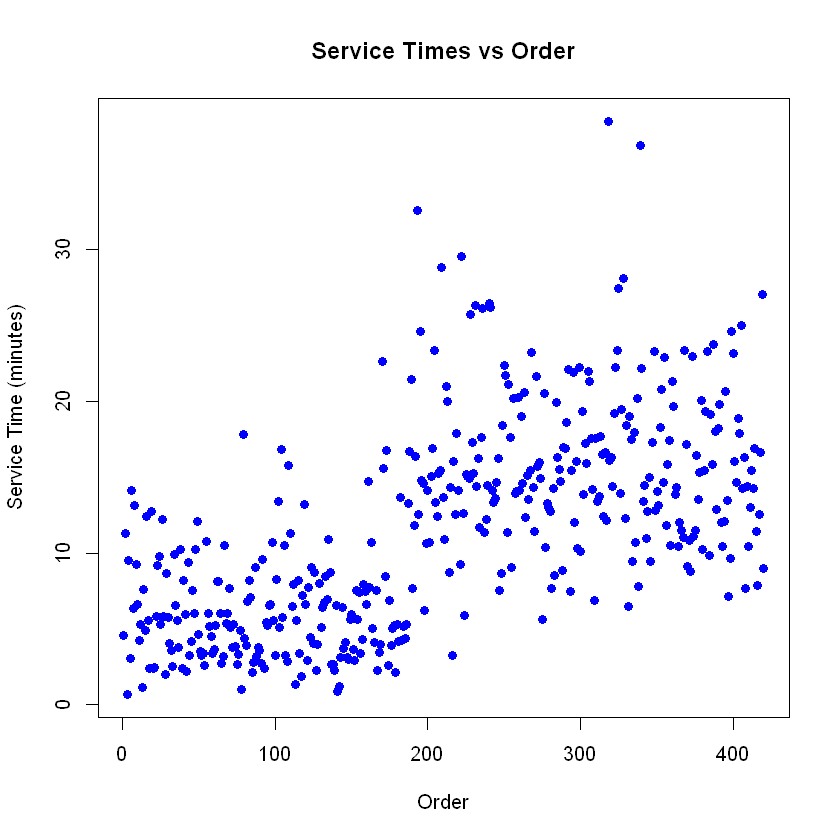

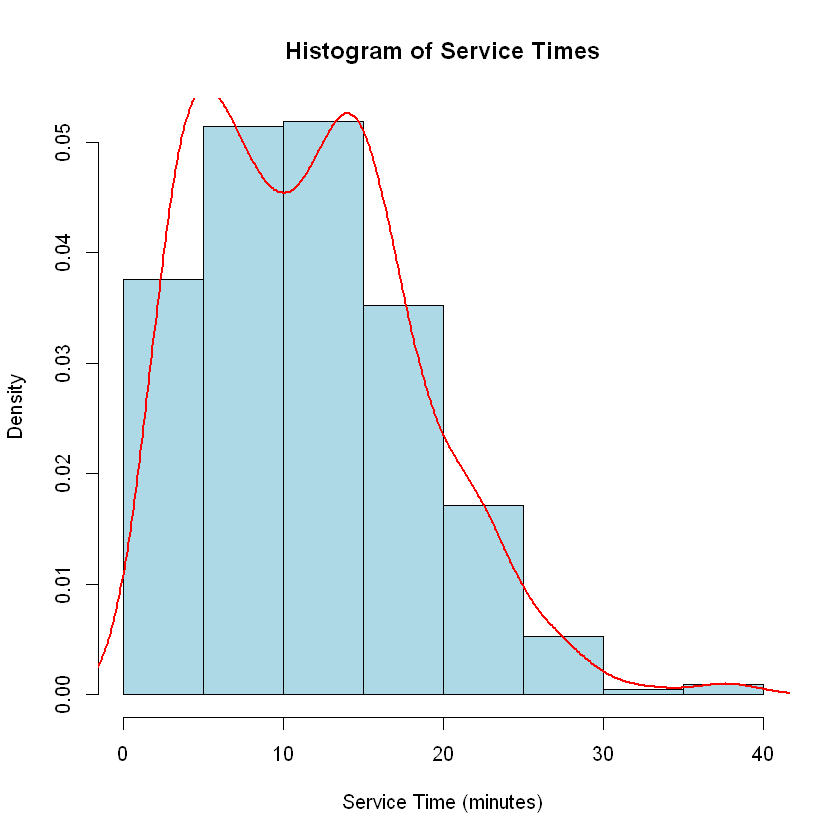

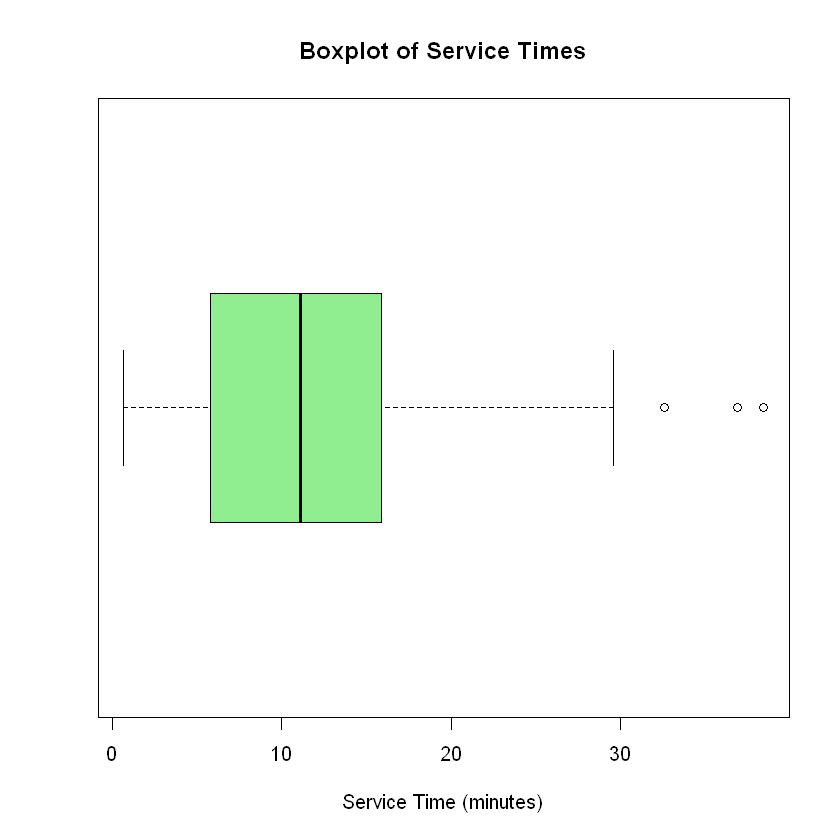

In [113]:
# Read the service times data
service <- read.csv("data/service_times.csv")
order <- service$order
serviceTime <- service$service_minutes
#Provide descriptive statistics for the service times
head(service)
summary(serviceTime)
mean(serviceTime)
var(serviceTime)
sd(serviceTime)
#Plot service times against order to visualize the data
plot(order, serviceTime, main = "Service Times vs Order", xlab = "Order", ylab = "Service Time (minutes)", pch = 19, col = "blue")
#Plot histogram with a density estimate
hist(serviceTime, breaks = 10, probability = TRUE, main = "Histogram of Service Times", xlab = "Service Time (minutes)", col = "lightblue")
lines(density(serviceTime), col = "red", lwd = 2)
#Plot a boxplot to visualize the distribution of service times
boxplot(serviceTime, horizontal = TRUE, main = "Boxplot of Service Times", xlab = "Service Time (minutes)", col = "lightgreen")


As shown above, the service times have a mean of 11.57 minutes and a median of 11.09 minutes, with values ranging from 0.68 to 38.45 minutes. The standard deviation is approximately 6.74 minutes, indicating substantial variability in service duration. The mean being slightly greater than the median is consistent with the right-skewness visible in the histogram. According to the histogram and density estimate, they both revealed an overall right-skewed distribution. The density curve also suggests two concentrations of service times rather than one clearly defined peak. The box plot is consistent with this right-skewness and shows the presence of unusually large service times in the upper tail. Most importantly, the plot of service time against observation order provides evidence of a change over time. In conclusion, the plot of service time against observation order provides evidence of a change over time. Earlier observations generally have lower service times and less variability, while around observations 190–200 there appears to be an upward shift in both the typical service time and its variability. After this point, service times tend to be higher and include several particularly large observations. This suggests that the service-time process may have changed partway through the sequence, although the exact location of the change cannot be determined from these plots alone.


**(b)** Fit Gamma and Exponential distributions to all service times. Report parameter estimates, fitted means, AIC, and KS distances. Add fitted densities to a histogram and make a QQ plot for each model. Use the shape and rate parameterization for the Gamma distribution.


[1] 2.544677

[1] 0.2198694

[1] 11.57358

[1] -1367.711

[1] 2739.422

...

Warning message in ks.test.default(serviceTime, "pgamma", shape = gammaShape, rate = gammaRate):
"ties should not be present for the one-sample Kolmogorov-Smirnov test"


D 
0.07810821

Warning message in ks.test.default(serviceTime, "pexp", rate = expRate):
"ties should not be present for the one-sample Kolmogorov-Smirnov test"


D 
0.1632619

Model,Shape,Rate,Mean,AIC,KS_Distance
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Gamma,2.544677,0.2198694,11.57358,2739.422,0.07810821
Exponential,NA,0.0864018,11.57383,2898.947,0.16326190


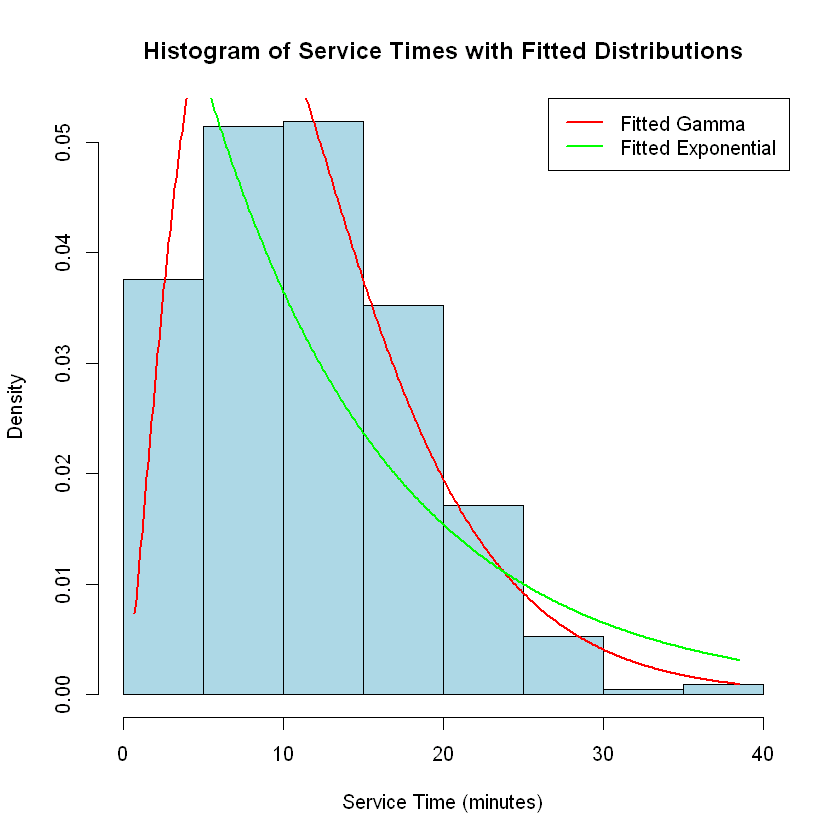

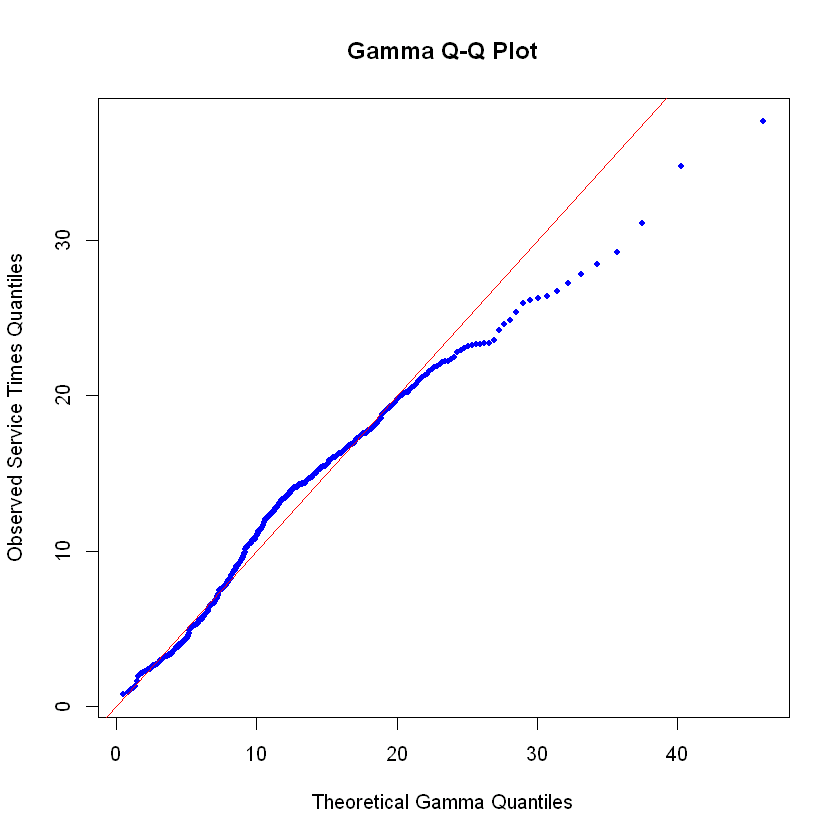

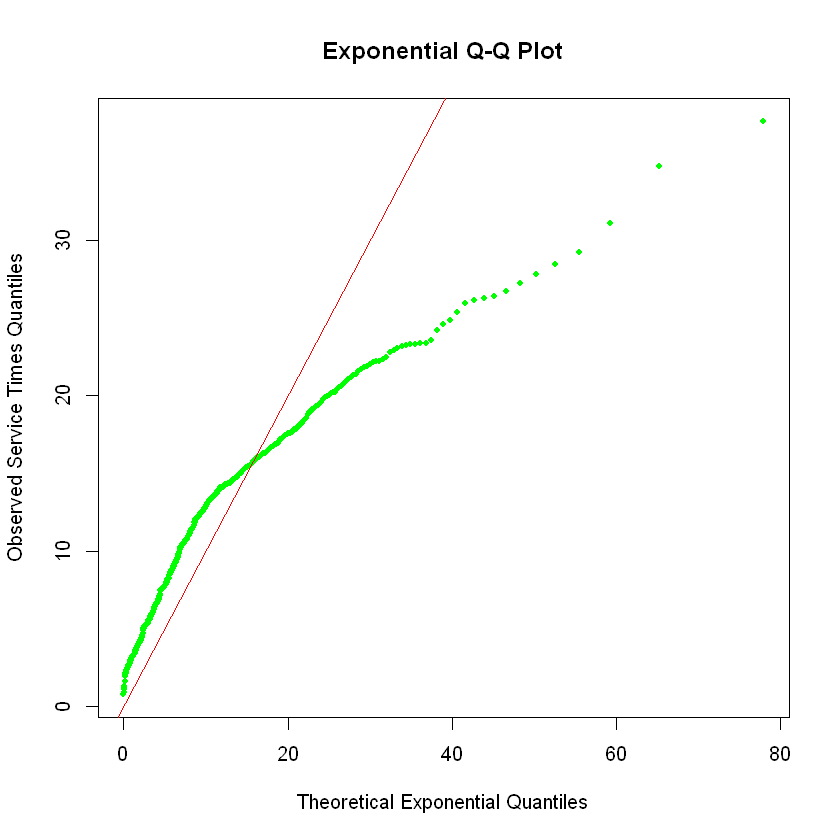

In [114]:
#Fit the gamma distribution to the service times data using maximum likelihood estimation
gammaLogLikelyhood <- function(par) {
  shape <- exp(par[1])
  rate <- exp(par[2])
  -sum(dgamma(serviceTime, shape = shape, rate = rate, log = TRUE))
}
#Estimate the parameters of the gamma distribution using the optim function
gammaFit <- optim(par = log(c(3, 0.25)), fn = gammaLogLikelyhood)
gammaShape <- exp(gammaFit$par[1])
gammaRate <- exp(gammaFit$par[2])
gammaShape
gammaRate
#Calculate the mean of the fitted gamma distribution
gammaMean <- gammaShape / gammaRate
gammaMean
#Calculate the log-likelihood and AIC for the fitted gamma distribution
logLikelyhoodGamma <- -gammaFit$value
aicGamma <- -2 * logLikelyhoodGamma + 2 * 2
logLikelyhoodGamma
aicGamma
#Calculate the rate parameter as the reciprocal of the mean service time
expRate <- 1 / mean(serviceTime)
expRate
#Calculate the mean of the fitted exponential distribution as the reciprocal of the rate parameter
expMean <- 1 / expRate
expMean
#Calculate the log-likelihood and AIC for the fitted exponential distribution
expLogLikelyhood <- sum(dexp(serviceTime, rate = expRate, log = TRUE))
aicExp <- -2 * expLogLikelyhood + 2 
expLogLikelyhood
aicExp
#Create a data frame to display the fitted parameters and AIC values for the gamma and exponential distributions
fitTable <- data.frame(
  Model = c("Gamma", "Exponential"), 
  Shape = c(gammaShape, NA),
  Rate = c(gammaRate, expRate),
  Mean = c(gammaMean, expMean), 
  AIC = c(aicGamma, aicExp)
)
fitTable
#Calculate the KS distances for the gamma and exponential distributions
ksGamma <- ks.test(serviceTime, "pgamma", shape = gammaShape, rate = gammaRate)
ksGamma$statistic
ksExp <- ks.test(serviceTime, "pexp", rate = expRate)
ksExp$statistic
#Add the KS distances to the fitTable data frame
fitTable$KS_Distance <- c(as.numeric(ksGamma$statistic), as.numeric(ksExp$statistic))
fitTable
#Create a sequence of x-values 
xValues <- seq(min(serviceTime), max(serviceTime), length.out = 500)
#Create a histogram of the service times with the fitted gamma and exponential distributions overlaid
hist(serviceTime, breaks = 10, probability = TRUE, main = "Histogram of Service Times with Fitted Distributions", xlab = "Service Time (minutes)", col = "lightblue")
#Overlay the fitted gamma and exponential distributions on the histogram
lines(xValues, dgamma(xValues, shape = gammaShape, rate = gammaRate), col = "red", lwd = 2)
lines(xValues, dexp(xValues, rate = expRate), col = "green", lwd = 2)
legend("topright", legend = c("Fitted Gamma", "Fitted Exponential"), col = c("red", "green"), lwd = 2)
#Create Gamma QQ plot that compares the quantiles of the service times to the quantiles of the fitted gamma distribution
numberObs <- length(serviceTime)
probPoints <- ppoints(numberObs)
observedQuantiles <- quantile(serviceTime, probPoints)
gammaQuantiles <- qgamma(ppoints(length(serviceTime)), shape = gammaShape, rate = gammaRate)
plot(gammaQuantiles, observedQuantiles, main = "Gamma Q-Q Plot", xlab = "Theoretical Gamma Quantiles", ylab = "Observed Service Times Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Create Exponential QQ plot that compares the quantiles of the service times to the quantiles of the fitted exponential distribution
expQuantiles <- qexp(ppoints(length(serviceTime)), rate = expRate)
plot(expQuantiles, observedQuantiles, main = "Exponential Q-Q Plot", xlab = "Theoretical Exponential Quantiles", ylab = "Observed Service Times Quantiles", pch = 16, col = "green", cex = 0.7)
abline(0, 1, col = "red", lwd = 1) 

Using the shape-rate parameterization, the fitted Gamma distribution has an estimated shape of $\hat{\alpha}\approx 2.5447$ and rate $\hat{\lambda}\approx 0.21987$. The fitted mean turned out to be $\frac{\hat{\alpha}}{\hat{\lambda}} =\frac{2.5447}{0.21987}\approx 11.5736$. Which is approximately 11.5736 minutes. The fitted Exponential distribution has estimated rate $\hat{\lambda}\approx 0.08640$, corresponding to a fitted mean of $\frac{1}{\hat{\lambda}}\approx 11.5738$ Which is approximately 11.5738 minutes. The Gamma model has an AIC of approximately 2739.422, compared with 2898.947 for the Exponential model. Because smaller AIC values indicate a preferable fit after accounting for the number of estimated parameters, the Gamma model is substantially better by this criterion. The Gamma model also has the smaller KS distance, approximately 0.0781, compared with 0.1633 for the Exponential model, indicating that its fitted CDF is closer to the empirical distribution. The fitted Gamma density follows the overall shape of the histogram considerably better than the Exponential density. The Gamma QQ plot follows the reference line reasonably well through much of the distribution, although systematic deviations remain, particularly in the upper tail. In contrast, the Exponential QQ plot shows strong systematic curvature away from the reference line, indicating substantial lack of fit. In conclusion, the Gamma distribution provides the better fit to the complete set of service times, although it does not describe the data perfectly. The remaining departures may partly reflect the apparent change in the service-time process identified in 2(a) as a single distribution is being fitted to all observations before accounting for a possible change over time.


**(c)** Search every possible split after rows 80 through 340. For each split, fit a Gamma distribution to each segment and record the sum of their log likelihoods. Select the split with the largest sum and plot this criterion against split position. Compare one Gamma model with the selected split using the exploratory score $k\log(n)-2\ell$, with $k=2$ for one model and $k=5$ for two segment models and a selected split. Explain why this search is not a formal test of a change.


[1] 186

[1] -1195.222

$shape
[1] 3.106257

$rate
[1] 0.4997902

$logLikelyhood
[1] -476.7191

$shape
[1] 8.499096

$rate
[1] 0.536797

$logLikelyhood
[1] -718.5028

[1] 6.215121

[1] 15.83298

[1] 2747.502

[1] 2420.645

Model,k,LogLikelyhood,Score
<chr>,<dbl>,<dbl>,<dbl>
One Gamma,2,-1367.711,2747.502
Split Gamma,5,-1195.222,2420.645


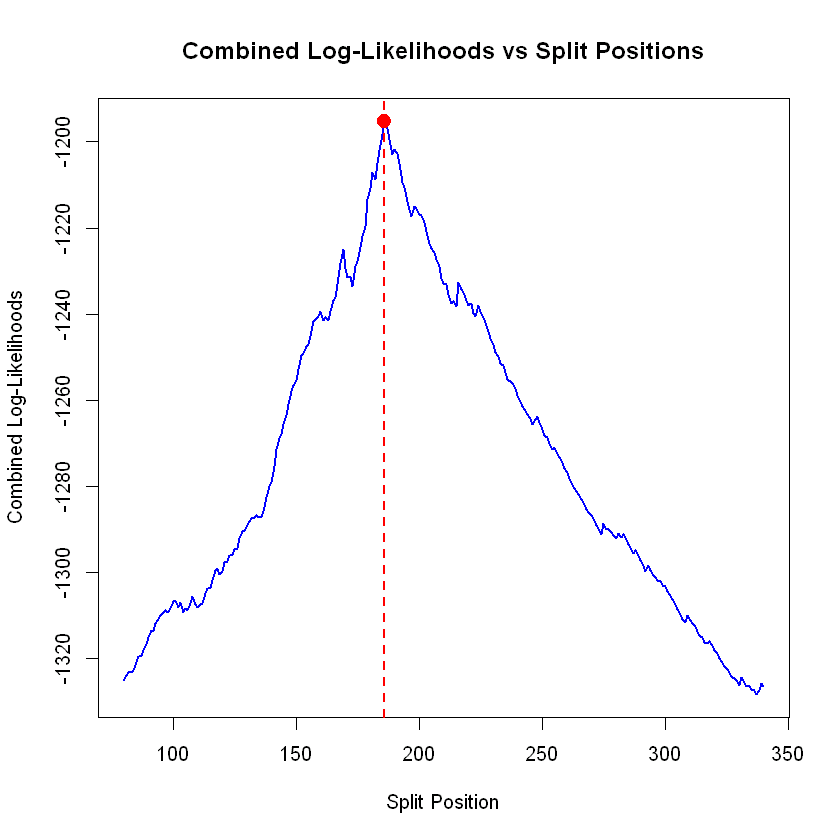

In [115]:

#Create a reusable Gamma fitting function that takes a vector of data as input and returns the estimated shape and rate parameters, as well as the log-likelihood of the fitted gamma distribution
fitGamma <- function(x) {
  gammaLogLikelyhood <- function(par) {
    shape <- exp(par[1])
    rate <- exp(par[2])
    -sum(dgamma(x, shape = shape, rate = rate, log = TRUE))
  }
  
  gammaFit <- optim(par = log(c(3, 0.25)), fn = gammaLogLikelyhood)
  gammaShape <- exp(gammaFit$par[1])
  gammaRate <- exp(gammaFit$par[2])
  logLikelyhoodGamma <- -gammaFit$value
  
  return(list(shape = gammaShape, rate = gammaRate, logLikelyhood = logLikelyhoodGamma))
}
#Create all possible split positions from rows 80 to 340 in the service times data frame
splitPositions <- 80:340
#Create empty vector to store the combined log-likelihoods for each split position
combineLikelyhoods <- numeric(length(splitPositions))
#Search for every possible split position and calculate the combined log-likelihoods for the two segments of the data
for (i in seq_along(splitPositions)) {
  splitPos <- splitPositions[i]
  segment1 <- serviceTime[1:splitPos]
  segment2 <- serviceTime[(splitPos + 1):length(serviceTime)]
  fit1 <- fitGamma(segment1)
  fit2 <- fitGamma(segment2)
  combineLikelyhoods[i] <- fit1$logLikelyhood+ fit2$logLikelyhood
}
#Find the best split position that maximizes the combined log-likelihoods
bestSplitIndex <- which.max(combineLikelyhoods)
bestSplitPosition <- splitPositions[bestSplitIndex]
bestLogLikelyhood <- combineLikelyhoods[bestSplitIndex]
bestSplitPosition
bestLogLikelyhood
#PLot the combined log-likelihoods against the split positions to visualize the results
plot(splitPositions, combineLikelyhoods, type = "l", main = "Combined Log-Likelihoods vs Split Positions", xlab = "Split Position", ylab = "Combined Log-Likelihoods", col = "blue", lwd = 2)
abline(v = bestSplitPosition, col = "red", lwd = 2, lty = 2)
#Include both vertical line and actual point of the best split position on the plot
points(bestSplitPosition, bestLogLikelyhood, col = "red", pch = 19, cex = 1.5)
#Fit the gamma distribution to the two segments of the service times data using the best split position
segment1 <- serviceTime[1:bestSplitPosition]
segment2 <- serviceTime[(bestSplitPosition + 1):length(serviceTime)]
fit1 <- fitGamma(segment1)
fit2 <- fitGamma(segment2)
fit1
fit2
#Calculate their fitted means
mean1 <- fit1$shape / fit1$rate
mean2 <- fit2$shape / fit2$rate
mean1
mean2
#Compare one gamma vs. split gamma
numberObs <- length(serviceTime)
# Fit one Gamma distribution to all service times
oneGammaFit <- fitGamma(serviceTime)
oneGammaLogLikelyhood <- oneGammaFit$logLikelyhood
#Calculate the scores for one gamma and split gamma
gamma1score <- 2 * log(numberObs) - 2 * oneGammaLogLikelyhood
gamma2score <- 5 * log(numberObs) - 2 * bestLogLikelyhood
gamma1score
gamma2score
#Make a comparison table for the one gamma vs. split gamma
comparisonTable <- data.frame(
  Model = c("One Gamma", "Split Gamma"),
  k = c(2, 5),
  LogLikelyhood = c(oneGammaLogLikelyhood, bestLogLikelyhood),
  Score = c(gamma1score, gamma2score)
)
comparisonTable

As I searched for all the possible positions from observations 80 to 340, I found out that for each candidate split, separate Gamma distributions were fitted to the observations before and after the split, and their maximized log-likelihoods were summed. The largest combined log-likelihood was approximately $\ell_{\text{split}}\approx -1195.222$ at a selected split of $s = 186$ Thus, the selected model divides the service times into observations 1–186 and 187–420. As shown above, the plot of combined log-likelihood against split position shows a clear maximum around observation 186. For the first segment, the fitted Gamma distribution has shape $\hat{\alpha}_1 \approx 3.1063$ and rate $\hat{\lambda}_1 \approx 0.4998$ Which gives a fitted mean of approximately 6.215 minutes. For the second segment, the fitted Gamma distribution has shape $\hat{\alpha}_2 \approx 8.4991$ and rate $\hat{\lambda}_2 \approx 0.5368$ Which gives a fitted mean of approximately 15.833 minutes. Thus, the fitted mean service time increases considerably after the selected split. Using $S = k\log(n) - 2\ell$ with $k = 2$ for one Gamma model and $k = 5$ for two Gamma models plus the selected split, the one-Gamma model has a score of approximately 2747.502, while the split-Gamma model has a score of approximately 2420.645. Since smaller values are preferred, the exploratory criterion formula favors the two-segment Gamma representation. However, this search is not a formal hypothesis test since the split at observation 186 was not specified in advance; it was selected after searching 261 candidate split positions and choosing the one that maximized the combined likelihood. Therefore, the analysis does not provide a null distribution or p-value accounting for the search over possible split locations. The result should consequently be interpreted as exploratory evidence of a change rather than a formal significance test.

**(d)** At your selected split, fit Gamma and Exponential models separately to each segment. Compare AIC within each segment, report parameter estimates and fitted means, and make density overlays and Gamma QQ plots. Estimate the probability of a service time longer than 15 minutes in each segment.


[1] 186

[1] 234

$shape
[1] 3.106257

$rate
[1] 0.4997902

$logLikelyhood
[1] -476.7191

$shape
[1] 8.499096

$rate
[1] 0.536797

$logLikelyhood
[1] -718.5028

[1] 0.1608927

...

[1] 1053.651

[1] 1762.666

[1] 957.4383

[1] 1441.006

Segment,Model,Shape,Rate,Mean,AIC
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Segment 1,Gamma,3.106257,0.49979024,6.215121,957.4383
Segment 1,Exponential,NA,0.16089269,6.215323,1053.6506
Segment 2,Gamma,8.499096,0.53679700,15.832979,1441.0056
Segment 2,Exponential,NA,0.06315858,15.833162,1762.6659


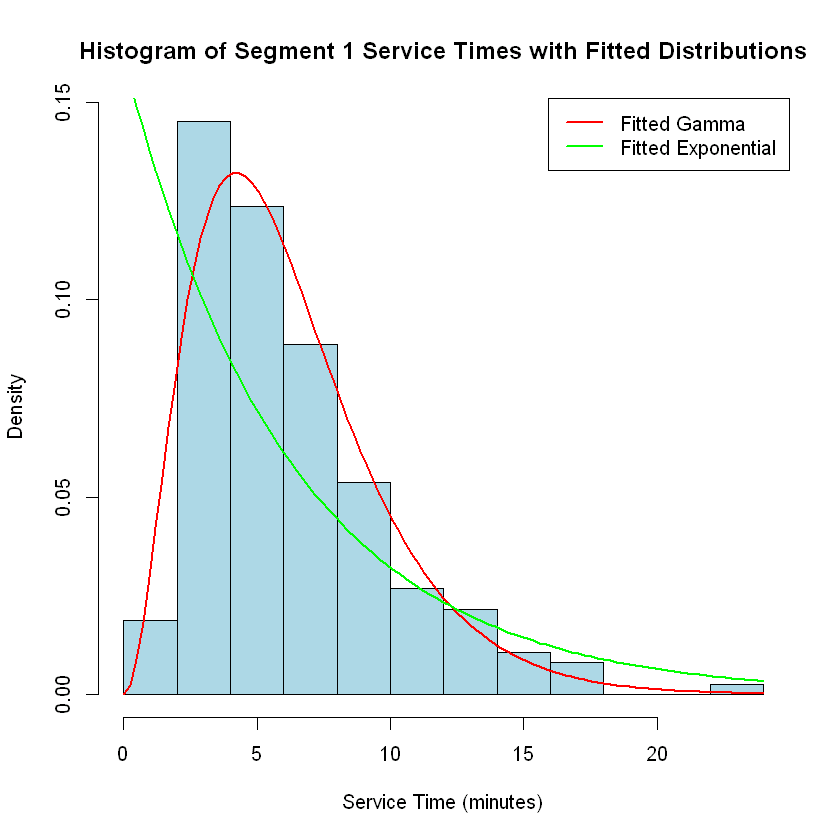

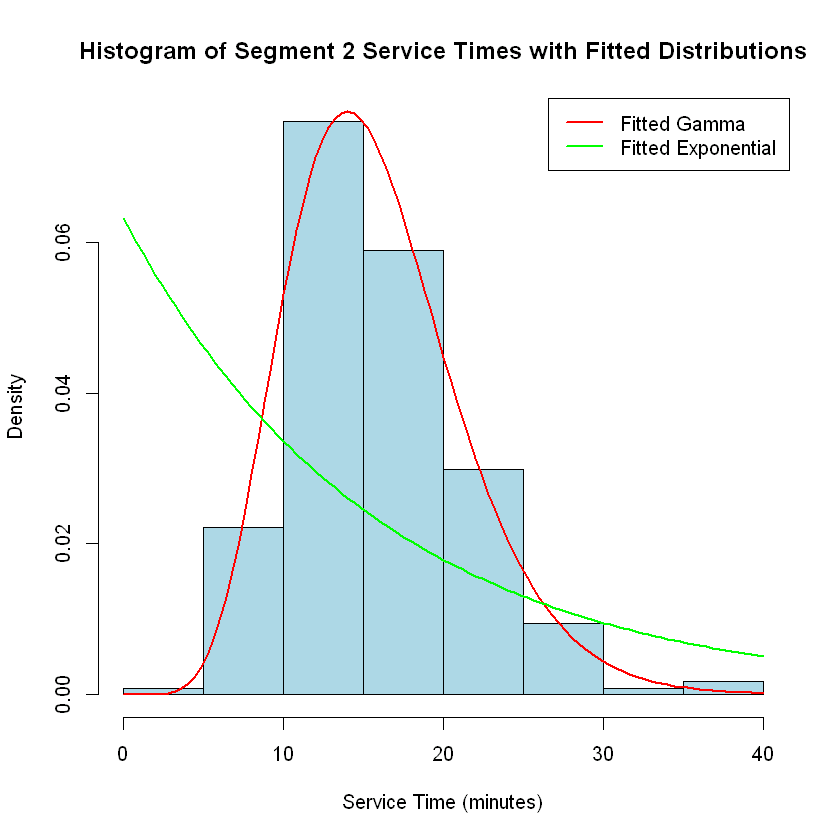

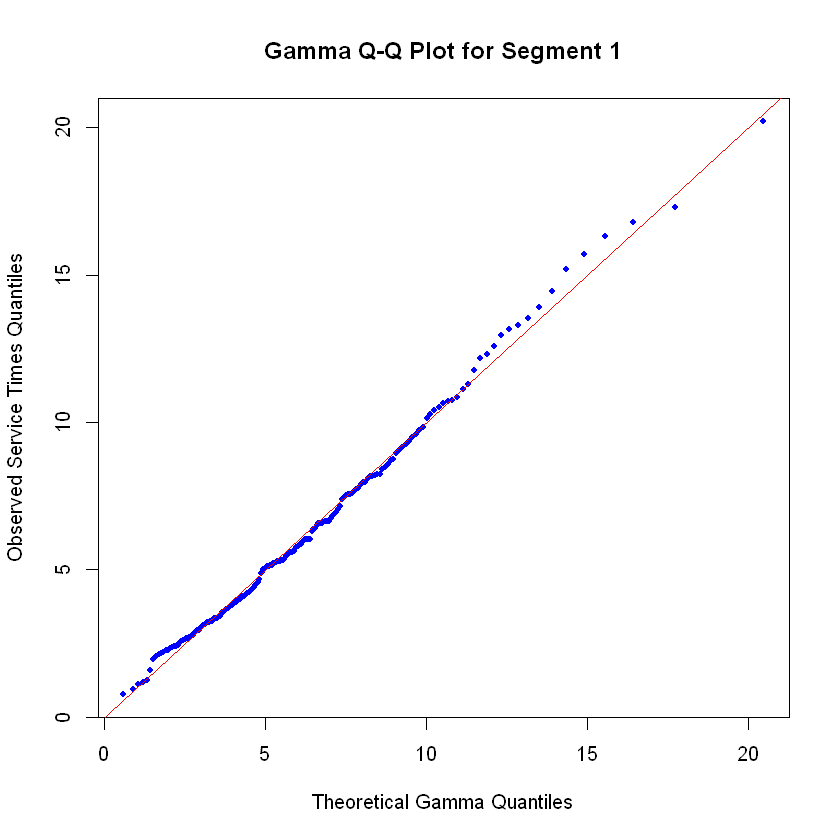

[1] 0.02311264

[1] 0.5163541

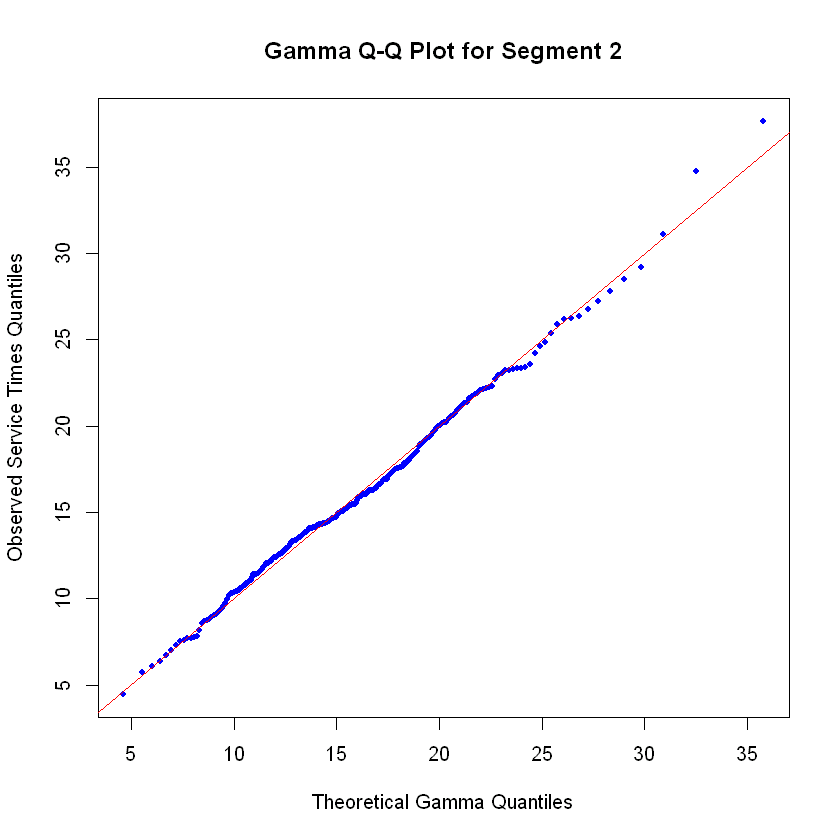

In [116]:

#Use segments from the previous part to fit exponential distributions by verifying sample sizes
segment1 <- serviceTime[1:bestSplitPosition]
segment2 <- serviceTime[(bestSplitPosition + 1):length(serviceTime)]
length(segment1)
length(segment2)
#State the gamma fits from the previous part too
fit1 <- fitGamma(segment1)
fit2 <- fitGamma(segment2)
fit1
fit2
#Fit exponential distribution to each segment using MLE of the rate
expRate1 <- 1 / mean(segment1)
expRate2 <- 1 / mean(segment2)
expRate1
expRate2
#Calculate the exponential log-likelihoods for each segment
expLogLikelyhood1 <- sum(dexp(segment1, rate = expRate1, log = TRUE))
expLogLikelyhood2 <- sum(dexp(segment2, rate = expRate2, log = TRUE))
expLogLikelyhood1
expLogLikelyhood2
#Calculate the AIC for each segment's exponential and gamma distribution
aicExp1 <- -2 * expLogLikelyhood1 + 2 
aicExp2 <- -2 * expLogLikelyhood2 + 2
aicGamma1 <- -2 * fit1$logLikelyhood + 2 * 2
aicGamma2 <- -2 * fit2$logLikelyhood + 2 * 2
aicExp1
aicExp2
aicGamma1
aicGamma2
#Now create a comparison table for the exponential and gamma distributions for each segment
comparisonTableSegments <- data.frame(
    Segment = c("Segment 1", "Segment  1", "Segment 2", "Segment 2"),
    Model = c("Gamma", "Exponential", "Gamma", "Exponential"),
    Shape = c(fit1$shape, NA, fit2$shape, NA),
    Rate = c(fit1$rate, expRate1, fit2$rate, expRate2),
    Mean = c(fit1$shape / fit1$rate, 1 / expRate1, fit2$shape / fit2$rate, 1 / expRate2),
    AIC = c(aicGamma1, aicExp1, aicGamma2, aicExp2)
)
comparisonTableSegments
#Now create density overlays for segment 1 only for observations 1-186
hist(segment1, probability = TRUE, breaks = 10, main = "Histogram of Segment 1 Service Times with Fitted Distributions", xlab = "Service Time (minutes)", col = "lightblue")
curve(dgamma(x, shape = fit1$shape, rate = fit1$rate), add = TRUE, col = "red", lwd = 2)
curve(dexp(x, rate = expRate1), add = TRUE, col = "green", lwd = 2)
legend("topright", legend = c("Fitted Gamma", "Fitted Exponential"), col = c("red", "green"), lwd = 2)
#Now create density overlays for segment 2 only for observations 187-420
hist(segment2, probability = TRUE, breaks = 10, main = "Histogram of Segment 2 Service Times with Fitted Distributions", xlab = "Service Time (minutes)", col = "lightblue")
curve(dgamma(x, shape = fit2$shape, rate = fit2$rate), add = TRUE, col = "red", lwd = 2)
curve(dexp(x, rate = expRate2), add = TRUE, col = "green", lwd = 2)
legend("topright", legend = c("Fitted Gamma", "Fitted Exponential"), col = c("red", "green"), lwd = 2)
#Create Gamma QQ plot for segment 1 to get probabilities corresponding to the quantiles of the fitted gamma distribution
numberObs1 <- length(segment1)
probPoints1 <- ppoints(numberObs1)
observedQuantiles1 <- quantile(segment1, probPoints1)
gammaQuantiles1 <- qgamma(ppoints(length(segment1)), shape = fit1$shape, rate = fit1$rate)
plot(gammaQuantiles1, observedQuantiles1, main = "Gamma Q-Q Plot for Segment 1", xlab = "Theoretical Gamma Quantiles", ylab = "Observed Service Times Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Create Gamma QQ plot for segment 2 to get probabilities corresponding to the quantiles of the fitted gamma distribution
numberObs2 <- length(segment2)
probPoints2 <- ppoints(numberObs2)
observedQuantiles2 <- quantile(segment2, probPoints2)
gammaQuantiles2 <- qgamma(ppoints(length(segment2)), shape = fit2$shape, rate = fit2$rate)
plot(gammaQuantiles2, observedQuantiles2, main = "Gamma Q-Q Plot for Segment 2", xlab = "Theoretical Gamma Quantiles", ylab = "Observed Service Times Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Find the probability of the service time being longer than 15 minutes for segment 1
probLongerThan15Seg1 <- 1 - pgamma(15, shape = fit1$shape, rate = fit1$rate)
probLongerThan15Seg1
#Find the probability of the service time being longer than 15 minutes for segment 2
probLongerThan15Seg2 <- 1 - pgamma(15, shape = fit2$shape, rate = fit2$rate)
probLongerThan15Seg2

At the selected split observation 186, gamma and exponential distributions were fitted separately to each segment. As shown above for segment 1, which included observations from 1 to 186, the Gamma model had an estimated shape of approximately 3.1063, a rate of approximately 0.4998, and a fitted mean of approximately 6.2151 minutes with an AIC of approximately 957.4383. The exponential model had an estimated rate of 0.1609, fitted mean 6.2153 minutes, and AIC of 1053.6506. Since the gamma model has the smaller AIC, it is preferred for Segment 1. As for segment 2, which included observations from 187 to 420, the gamma model had an estimated shape of approximately 8.4991, a rate of approximately 0.5368, and a fitted mean of approximately 15.8330 minutes with an AIC of approximately 1762.6659. The gamma model once again has the smaller AIC and is therefore preferred for segment 2. 


**(e)** Describe what the split suggests about service operations. Explain how a report based on all observations together could misrepresent the more recent service times. Identify information you would want before attributing the difference to a particular cause.


The split at observation 186 suggests that there was a noticeable change in the service operations over time. Before the split, the fitted mean service time was about 6.22 minutes, while after the split it increased to about 15.83 minutes. There was also only about a 2.31% chance of a service time lasting longer than 15 minutes before the split, compared to about 51.64% after the split. Based on these results and the pattern I observed in the plot from 2(a), it seems that the later service times were generally much longer than the earlier ones. This is also why combining all 420 observations into one report could be misleading, especially if the goal is to describe the more recent service times. The overall mean was about 11.57 minutes, but that value mixes the shorter service times from the earlier observations with the much longer service times from the later observations. Because the fitted mean after the split was about 15.83 minutes, reporting only the overall mean of 11.57 minutes would make the more recent service times look shorter than they actually are. However, I would not immediately assume that a specific operational problem caused this change just from these results. The data show that the service-time pattern changed, but they do not explain why it changed. Before connecting the difference to a particular cause, I would want more information about what was happening around observation 186, such as staffing or shift changes, customer volume, differences in the types or complexity of services, new procedures or policies, and possible equipment or system issues. This extra information would help determine what may have contributed to the longer service times rather than assuming a cause based only on the statistical pattern.


## Question 3
### Old Faithful

The file `faithful.csv` contains eruption durations and the time until the next eruption at Old Faithful. Both variables are measured in minutes.


**(a)** Make histograms and box plots of eruption duration and waiting time, and a scatterplot of waiting time against eruption duration. Describe the relationship.


,eruptions,waiting
,<dbl>,<int>
1,3.600,79
2,1.800,54
3,3.333,74
4,2.283,62
5,4.533,85
6,2.883,55


[1] 272

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.600   2.163   4.000   3.488   4.454   5.100 

[1] 3.487783

[1] 1.302728

...

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   43.0    58.0    76.0    70.9    82.0    96.0 

[1] 70.89706

[1] 184.8233

[1] 13.59497

[1] 0.9008112

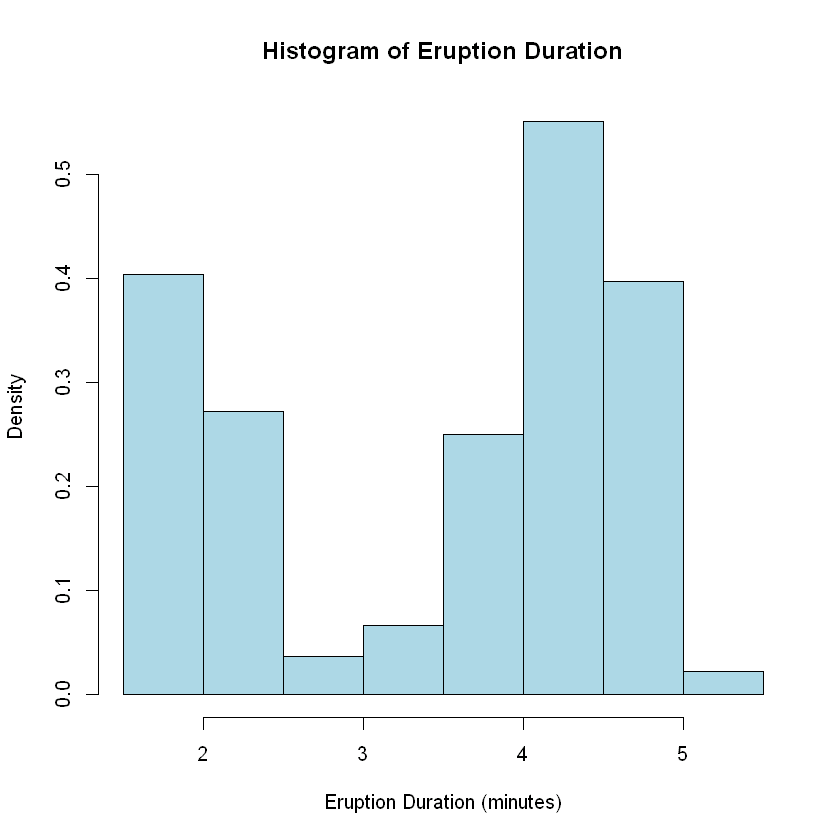

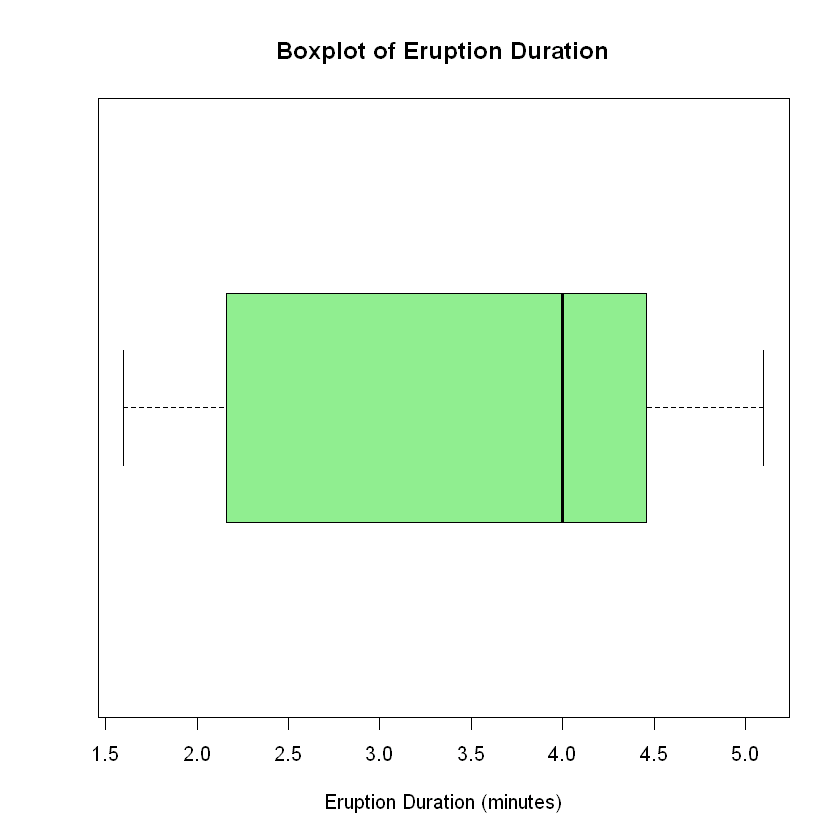

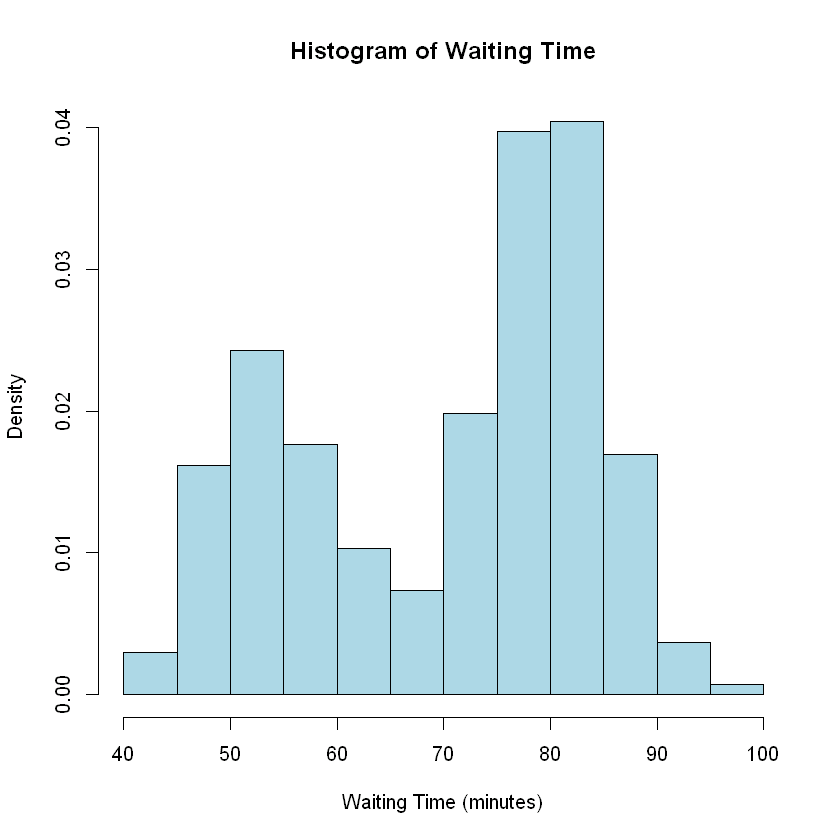

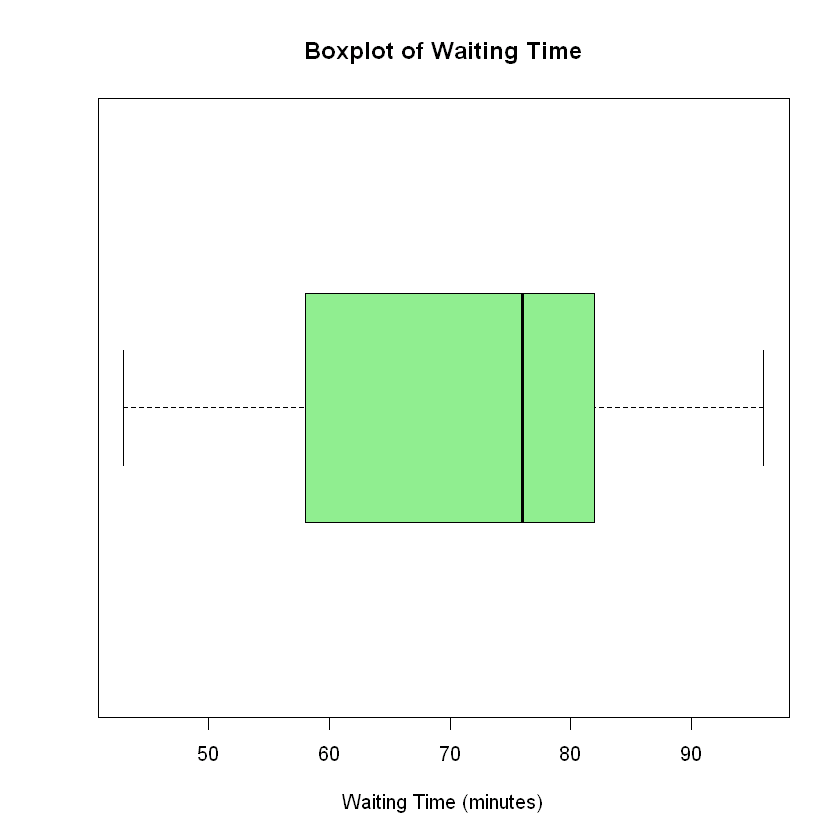

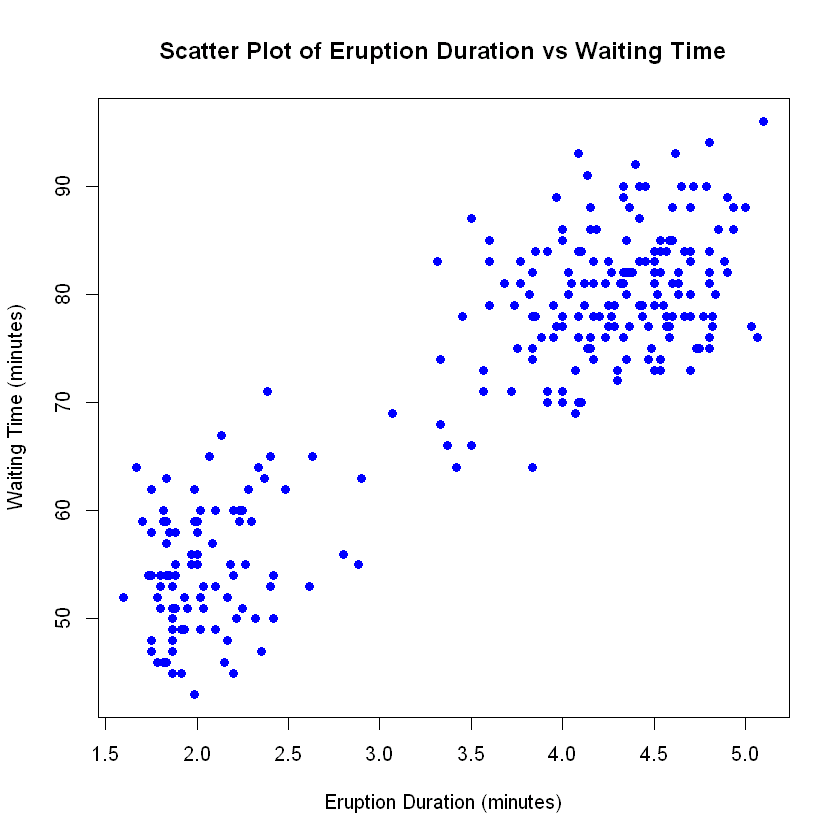

In [117]:
#Read the faithful data and extract the eruption durations and waiting times
faithful <- read.csv("data/faithful.csv")
eruptionDuration <- faithful$eruptions
waitingTime <- faithful$waiting
head(faithful)
nrow(faithful)
#Now get the descriptive statistics for the eruption durations and waiting times
summary(eruptionDuration)
mean(eruptionDuration)
var(eruptionDuration)
sd(eruptionDuration)
summary(waitingTime)
mean(waitingTime)
var(waitingTime)
sd(waitingTime)
#Describe the relationship between them
cor(eruptionDuration, waitingTime)
#Create a histogram and boxplot of the eruption duration
hist(eruptionDuration, breaks = 10, probability = TRUE, main = "Histogram of Eruption Duration", xlab = "Eruption Duration (minutes)", col = "lightblue")
boxplot(eruptionDuration, horizontal = TRUE, main = "Boxplot of Eruption Duration", xlab = "Eruption Duration (minutes)", col = "lightgreen")
#Create a histogram and boxplot of the waiting time
hist(waitingTime, breaks = 10, probability = TRUE, main = "Histogram of Waiting Time", xlab = "Waiting Time (minutes)", col = "lightblue")
boxplot(waitingTime, horizontal = TRUE, main = "Boxplot of Waiting Time", xlab = "Waiting Time (minutes)", col = "lightgreen")
#Create a scatter plot of the eruption duration against the waiting time to visualize the relationship between them
plot(eruptionDuration, waitingTime, main = "Scatter Plot of Eruption Duration vs Waiting Time", xlab = "Eruption Duration (minutes)", ylab = "Waiting Time (minutes)", pch = 19, col = "blue")

As shown above, the histograms of the eruption duration and waiting time distributions both appear to be bimodal rather than having one single peak. Eruption durations form one group of shorter eruptions around 1.5–2.5 minutes and another group of longer eruptions around 3.5–5 minutes. The average eruption duration is approximately 3.49 minutes, while the average waiting time is approximately 70.90 minutes. Waiting times show a similar pattern, with one group of shorter waiting times and another group of longer waiting times. The boxplots summarize the spread of both variables, although the two separate groups are much more noticeable in the histograms. The scatterplot also shows a strong positive relationship between eruption duration and waiting time. Longer eruptions generally correspond to longer waiting times before the next eruption, while shorter eruptions tend to correspond to shorter waiting times. The correlation is approximately $r\approx 0.901$ Which supports the strong positive association seen in the scatterplot. However, the points do not form one single group because there are two noticeable clusters representing shorter and longer eruption patterns.


**(b)** Fit a Normal distribution and a location and scale Student t distribution to waiting time. Fix the t degrees of freedom at 5 and estimate its location and scale. Compare AIC and QQ plots. Explain what fixing the degrees of freedom at 5 implies about the tails, and distinguish the t scale from its standard deviation.


[1] 70.89706

[1] 13.56996

[1] -1095.289

[1] 2194.578

[1] 72.11322

[1] 12.45387

[1] -1110.675

[1] 2225.349

Model,Location,Scale,AIC
<chr>,<dbl>,<dbl>,<dbl>
Normal,70.89706,13.56996,2194.578
Student t with 5 df,72.11322,12.45387,2225.349


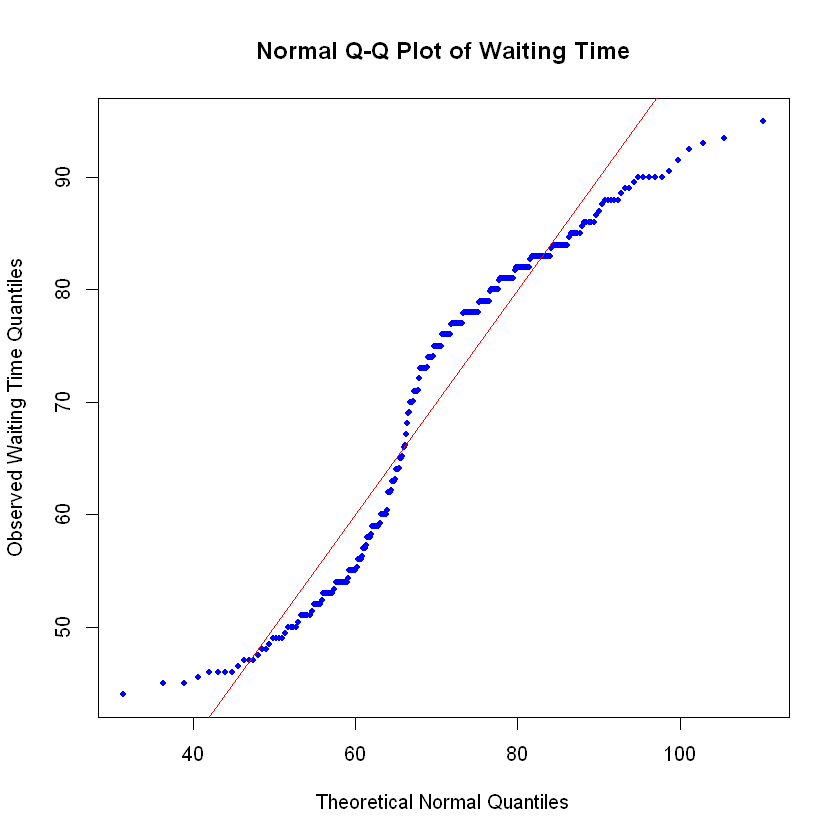

[1] 16.07787

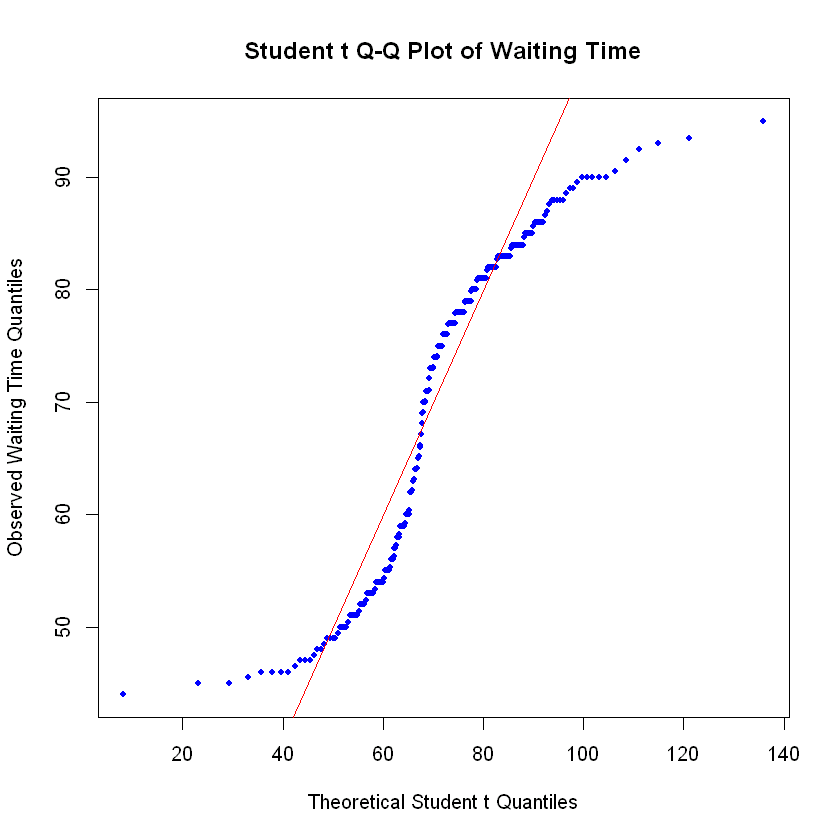

In [118]:
#Fit a normal distribution to the waiting time data and calculate the mean and standard deviation
normalMean <- mean(waitingTime)
normalSD <- sqrt(mean((waitingTime- normalMean)^2))
normalMean
normalSD
#Calculate the normal log-likelihood and AIC for the fitted normal distribution
normalLogLikelyhood <- sum(dnorm(waitingTime, mean = normalMean, sd = normalSD, log = TRUE))
aicNormal <- -2 * normalLogLikelyhood + 2 * 2
normalLogLikelyhood
aicNormal
#Fix the number of degrees of freedom for the t-distribution to 5 and create negative log-likelihood function for the t-distribution
degreesFreedom <- 5
tNegLogLikelyhood <- function(par) {
  location <- par[1]
  scale <- exp(par[2])
  -sum(dt((waitingTime - location) / scale, df = degreesFreedom, log = TRUE) - log(scale))
}
#Estimate the parameters of the t-distribution using the optim function
tFit <- optim(par = c(normalMean, log(normalSD)), fn = tNegLogLikelyhood)
tLocation <- tFit$par[1]
tScale <- exp(tFit$par[2])
tLogLikelyhood <- -tFit$value
tLocation
tScale
tLogLikelyhood
#Calculate the AIC for the fitted t-distribution
aicT <- -2 * tLogLikelyhood + 2 * 2
aicT
#Create a data frame to display the fitted parameters and AIC values for the normal and student t models
fitTable <- data.frame(
  Model = c("Normal", "Student t with 5 df"),
  Location = c(normalMean, tLocation),
  Scale = c(normalSD, tScale),
  AIC = c(aicNormal, aicT)
)
fitTable
#Create a normal Q-Q plot to assess the fit of the normal distribution to the waiting time data
numberObs <- length(waitingTime)
probPoints <- ppoints(numberObs)
observedQuantiles <- quantile(waitingTime, probPoints)
normalQuantiles <- qnorm(probPoints, mean = normalMean, sd = normalSD)
plot(normalQuantiles, observedQuantiles, main = "Normal Q-Q Plot of Waiting Time", xlab = "Theoretical Normal Quantiles", ylab = "Observed Waiting Time Quantiles", pch = 16, col = "blue", cex = 0.7)   
abline(0, 1, col = "red", lwd = 1)
#Create a student t Q-Q plot to assess the fit of the t-distribution to the waiting time data
tQuantiles <- tLocation + tScale * qt(probPoints, df = degreesFreedom)
plot(tQuantiles, observedQuantiles, main = "Student t Q-Q Plot of Waiting Time", xlab = "Theoretical Student t Quantiles", ylab = "Observed Waiting Time Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Since we need to know that t scale isn't the same as t sd, we can calculate the t sd using the formula: t sd = t scale * sqrt(df / (df - 2)) for df > 2
tSD <- tScale * sqrt(degreesFreedom / (degreesFreedom - 2))
tSD

After fitting both distributions to waiting time, the Normal model had an estimated mean of approximately 70.90 minutes and standard deviation of approximately 13.57 minutes, with an AIC of 2194.58. The Student $t$ model with 5 degrees of freedom had an estimated location of approximately 72.11 minutes and scale of approximately 12.45, with an AIC of 2225.35. Since the Normal model has the lower AIC, it provides a better fit than the $t_5$ model out of these two choices. However, the Normal QQ plot still shows noticeable systematic curvature away from the reference line, so this does not mean that waiting time follows a Normal distribution particularly well. This makes sense based on the bimodal pattern I observed in 3(a). The Student $t$ QQ plot also shows substantial departures from the reference line. Fixing the degrees of freedom at 5 means that the tail behavior of the Student $t$ distribution is specified rather than estimated from the data. A $t_5$ distribution has heavier tails than a Normal distribution, so it allows more probability for observations farther away from the center. Also, the $t$ scale parameter is not the same as its standard deviation. With $df = 5$, the standard deviation is $s\sqrt{5/3}$. Using the fitted scale of approximately 12.45 gives a standard deviation of approximately 16.08 minutes.


**(c)** Use eruption durations alone to divide the observations into short and long eruptions. Find the largest gap between consecutive sorted durations whose midpoint lies between 2.5 and 4 minutes. Use that midpoint as the cutoff. Fit a Normal distribution to waiting times within each group and compare the group QQ plots with the pooled QQ plot.


[1] 1.600 1.667 1.700 1.733 1.750 1.750

[1] 4.933 4.933 5.000 5.033 5.067 5.100

[1] 3.192

[1] 3.067

[1] 3.317

...

[1] 54.64286

[1] 5.961184

[1] 80.05172

[1] 5.935736

Group,Mean,SD,NumberObs
<chr>,<dbl>,<dbl>,<int>
Short Eruptions,54.64286,5.961184,98
Long Eruptions,80.05172,5.935736,174


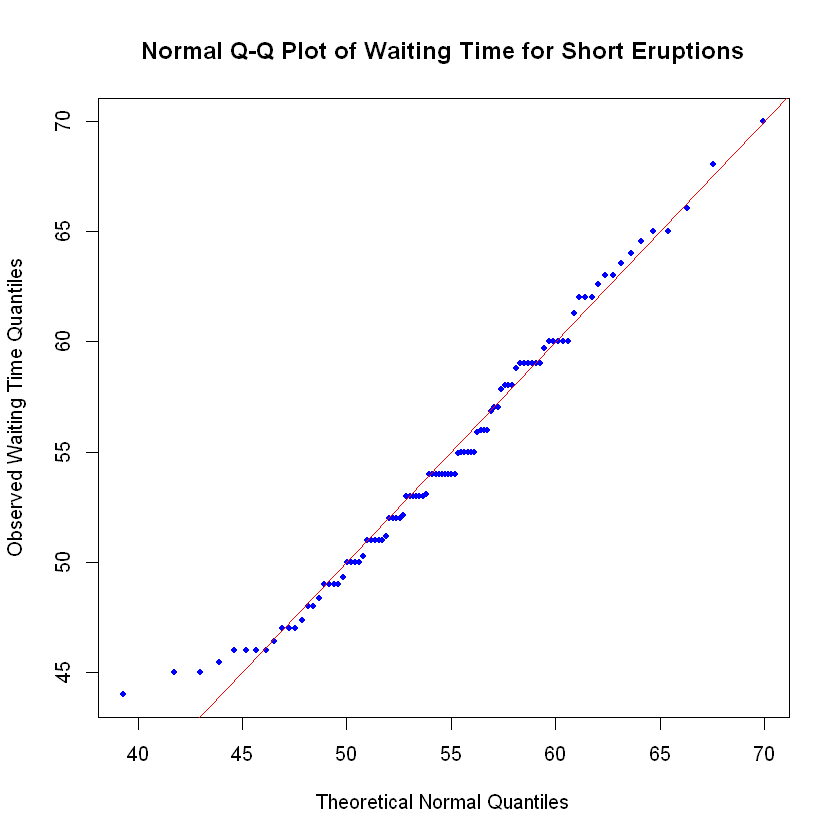

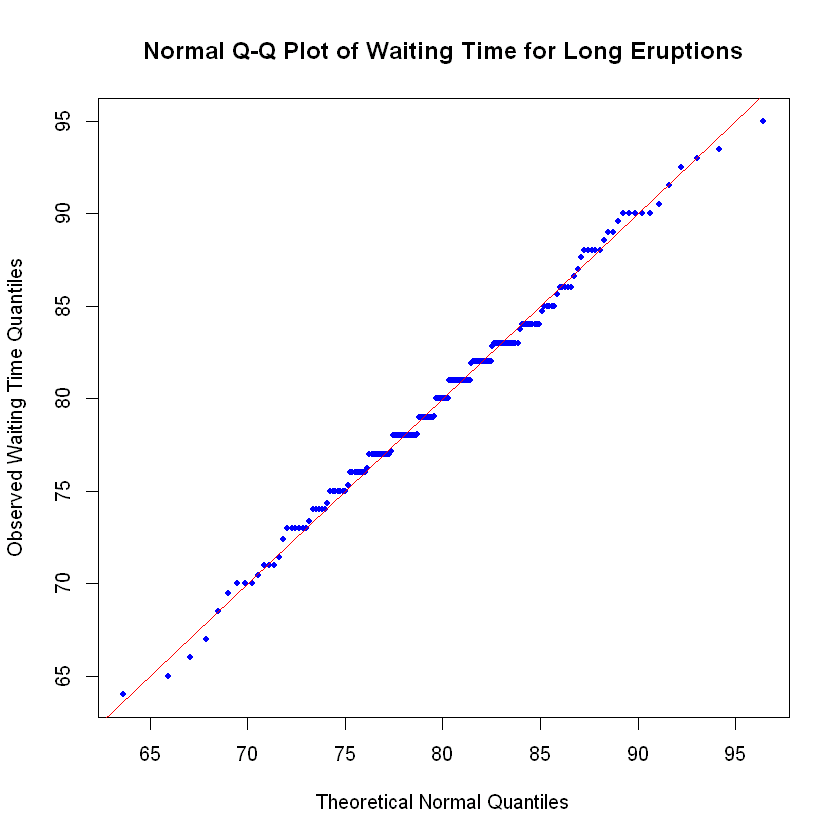

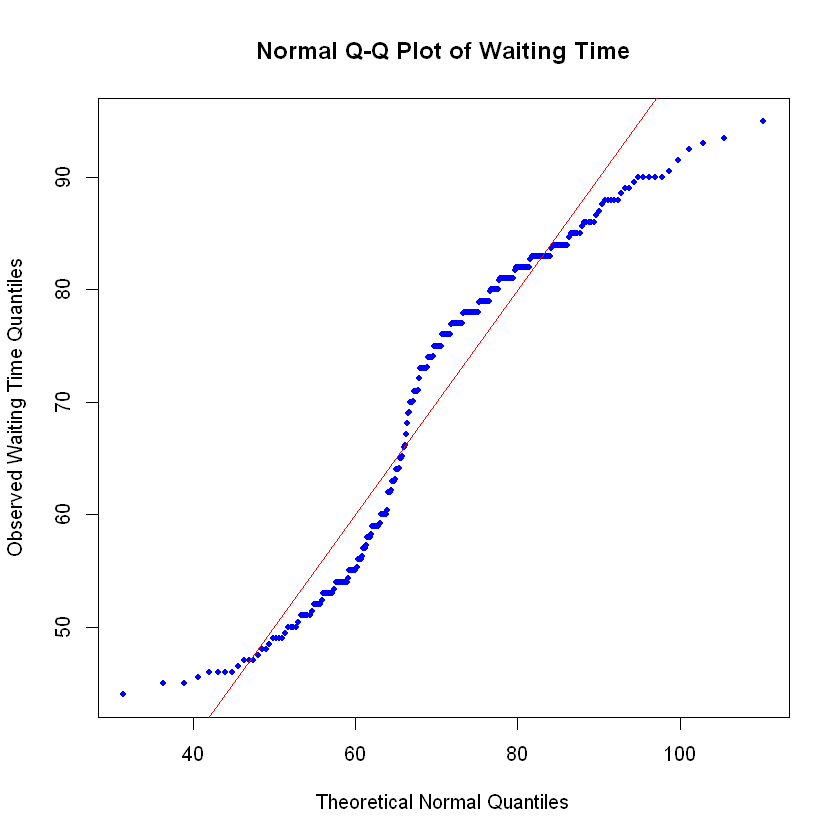

In [119]:
#Find the equation of the eruption duration cutoff by sorting it out first
sortedEruptionDuration <- sort(eruptionDuration)
head(sortedEruptionDuration)
tail(sortedEruptionDuration)
#Calculate the gaps between every pair of consecutive values in the sorted eruption durations to find the largest gap
gaps <- diff(sortedEruptionDuration)
#Let's solve for the largest gap where the midpoint falls between 2.5 and 4
gapMidpoints <- (sortedEruptionDuration[-length(sortedEruptionDuration)] + sortedEruptionDuration[-1]) / 2
validGaps <- which(gapMidpoints >= 2.5 & gapMidpoints <= 4)
largestGapIndex <- validGaps[which.max(gaps[validGaps])]
largestGapMidpoint <- gapMidpoints[largestGapIndex]
largestGapMidpoint
#Find out the 2 eruption durations surrounding that gap and its midpoint
lowerDuration <- sortedEruptionDuration[largestGapIndex]
upperDuration <- sortedEruptionDuration[largestGapIndex + 1]
cutoff <- gapMidpoints[largestGapIndex]
lowerDuration
upperDuration
gaps[largestGapIndex]
cutoff
#Use the cutoff to classify eruptions to each observation based on its eruption duration
eruptionGroup <- ifelse(eruptionDuration <= cutoff, "Short", "Long")
table(eruptionGroup)
#Use eruption duration to create groups instead of waiting time
waitingTimeShort <- waitingTime[eruptionGroup == "Short"]
waitingTimeLong <- waitingTime[eruptionGroup == "Long"]
length(waitingTimeShort)
length(waitingTimeLong)
#Fit a normal distribution to each group's waiting times
shortWaitingTimeMean <- mean(waitingTimeShort)
shortWaitingTimeSD <- sqrt(mean((waitingTimeShort - shortWaitingTimeMean)^2))
shortWaitingTimeMean
shortWaitingTimeSD
longWaitingTimeMean <- mean(waitingTimeLong)
longWaitingTimeSD <- sqrt(mean((waitingTimeLong - longWaitingTimeMean)^2))
longWaitingTimeMean
longWaitingTimeSD
#Create a normal group table of the short and long eruption durations
normalGroupTable <- data.frame(
    Group = c("Short Eruptions", "Long Eruptions"),
    Mean = c(shortWaitingTimeMean, longWaitingTimeMean),
    SD = c(shortWaitingTimeSD, longWaitingTimeSD),
    NumberObs = c(length(waitingTimeShort), length(waitingTimeLong))
)
normalGroupTable
#Make the QQ plot for the short-eruption group
numberShort <- length(waitingTimeShort)
probShort <- ppoints(numberShort)
observedShort <- quantile(waitingTimeShort, probShort)
normalShort <- qnorm(probShort, mean = shortWaitingTimeMean, sd = shortWaitingTimeSD)
plot(normalShort, observedShort, main = "Normal Q-Q Plot of Waiting Time for Short Eruptions", xlab = "Theoretical Normal Quantiles", ylab = "Observed Waiting Time Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Make another QQ plot for the long-eruption group
numberLong <- length(waitingTimeLong)
probLong <- ppoints(numberLong)
observedLong <- quantile(waitingTimeLong, probLong)
normalLong <- qnorm(probLong, mean = longWaitingTimeMean, sd = longWaitingTimeSD)
plot(normalLong, observedLong, main = "Normal Q-Q Plot of Waiting Time for Long Eruptions", xlab = "Theoretical Normal Quantiles", ylab = "Observed Waiting Time Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Compared with the pooled plot made from 3(b)
plot(normalQuantiles, observedQuantiles, main = "Normal Q-Q Plot of Waiting Time", xlab = "Theoretical Normal Quantiles", ylab = "Observed Waiting Time Quantiles", pch = 16, col = "blue", cex = 0.7)   
abline(0, 1, col = "red", lwd = 1)

As shown above, the largest qualifying gap between consecutive sorted eruption durations occurred between 3.067 and 3.317 minutes, with a gap of 0.250 minutes. Its midpoint is 3.192 minutes, so I used 3.192 as the cutoff between short and long eruptions. This resulted in 98 short eruptions and 174 long eruptions. The waiting times for short eruptions had a fitted Normal mean of approximately 54.64 minutes and standard deviation of approximately 5.96 minutes, while the waiting times for long eruptions had a fitted mean of approximately 80.05 minutes and standard deviation of approximately 5.94 minutes. The separate QQ plots for both groups follow the Normal reference line much more closely than the pooled QQ plot. The pooled plot shows strong systematic curvature because it combines observations from two groups with substantially different mean waiting times. Therefore, separating the observations using eruption duration reveals that waiting times within each group are much closer to a Normal distribution than the waiting times are when all observations are analyzed together.


**(d)** Report each group's sample size, fitted mean, and fitted standard deviation. Estimate the probability that the wait until the next eruption exceeds 70 minutes for each group. Compare the estimates with the observed proportions.


In [120]:
#Report the grap stats while reusing the normal group table of the short and long eruption durations
normalGroupTable <- data.frame(
    Group = c("Short Eruptions", "Long Eruptions"),
    Mean = c(shortWaitingTimeMean, longWaitingTimeMean),
    SD = c(shortWaitingTimeSD, longWaitingTimeSD),
    NumberObs = c(length(waitingTimeShort), length(waitingTimeLong))
)
normalGroupTable
#Estimate P(W > 70) from each fitted model by calculating the fitted probability that the waiting time exceeds 70 minutes 
probAbove70Short <- 1- pnorm(70, mean = shortWaitingTimeMean, sd = shortWaitingTimeSD)
probAbove70Long <- 1 - pnorm(70, mean = longWaitingTimeMean, sd = longWaitingTimeSD)
probAbove70Short
probAbove70Long
#Calculate the observed proportions 
observedAbove70Short <- mean(waitingTimeShort > 70)
observedAbove70Long <- mean(waitingTimeLong > 70)
observedAbove70Short
observedAbove70Long
#See the actual counts
sum(waitingTimeShort > 70)
sum(waitingTimeLong > 70)
#Make one final comparison table with observed proportions
probabilityTable <- data.frame(
    Group = c("Short Eruptions", "Long Eruptions"),
    Mean = c(shortWaitingTimeMean, longWaitingTimeMean),
    SD = c(shortWaitingTimeSD, longWaitingTimeSD),
    NumberObs = c(length(waitingTimeShort), length(waitingTimeLong)),
    FittedProbAbove70 = c(probAbove70Short, probAbove70Long),
    ObservedPropAbove70 = c(observedAbove70Short, observedAbove70Long) 
)
probabilityTable

Group,Mean,SD,NumberObs
<chr>,<dbl>,<dbl>,<int>
Short Eruptions,54.64286,5.961184,98
Long Eruptions,80.05172,5.935736,174


[1] 0.004994786

[1] 0.9548127

[1] 0.01020408

[1] 0.9425287

[1] 1

[1] 164

Group,Mean,SD,NumberObs,FittedProbAbove70,ObservedPropAbove70
<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
Short Eruptions,54.64286,5.961184,98,0.004994786,0.01020408
Long Eruptions,80.05172,5.935736,174,0.954812718,0.94252874


As shown above, the short-eruption group contained 98 observations, with a fitted mean waiting time of approximately 54.64 minutes and a fitted standard deviation of approximately 5.96 minutes. Based on the fitted Normal distribution, the estimated probability that the waiting time exceeds 70 minutes is approximately 0.0050, or 0.50%. The observed proportion is approximately 0.0102, or 1.02%, since only 1 out of 98 observations had a waiting time greater than 70 minutes. The long-eruption group contained 174 observations, with a fitted mean waiting time of approximately 80.05 minutes and a fitted standard deviation of approximately 5.94 minutes. The fitted Normal model estimates the probability of waiting longer than 70 minutes to be approximately 0.9548, or 95.48%. The observed proportion is approximately 0.9425, or 94.25%, since 164 out of 174 observations exceeded 70 minutes. Overall, the fitted and observed proportions are fairly close, especially for the long-eruption group. There is also a clear difference between the two groups: waiting more than 70 minutes is very uncommon after a short eruption but very common after a long eruption. This is consistent with the separation between the two groups that was already visible in the plots from the previous parts.


**(e)** Use a Welch t interval to estimate the difference in mean waiting time, long eruptions minus short eruptions. State the assumptions and interpret the interval. Explain why the result describes an association rather than the effect of changing eruption duration.


In [121]:
#Run the Welch two-sample t procedure by calculating a Welch t interval for the difference in mean waiting times
welchTest <- t.test(waitingTimeLong, waitingTimeShort, alternative = "two.sided", conf.level = 0.95, var.equal = FALSE)
welchTest
#Calculate estimated difference using fitted means
meanDifference <- mean(waitingTimeLong) - mean(waitingTimeShort)
meanDifference
#Extract 95% confidence interval
confidenceInterval <- welchTest$conf.int
confidenceInterval
#Display other Welch statistics
welchTest$statistic
welchTest$parameter
welchTest$conf.int
welchTest$estimate


	Welch Two Sample t-test

data:  waitingTimeLong and waitingTimeShort
t = 33.655, df = 200.14, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 23.92012 26.89762
sample estimates:
mean of x mean of y 
 80.05172  54.64286 


[1] 25.40887

[1] 23.92012 26.89762
attr(,"conf.level")
[1] 0.95

t 
33.65468

df 
200.1443

[1] 23.92012 26.89762
attr(,"conf.level")
[1] 0.95

mean of x mean of y 
 80.05172  54.64286

A Welch two-sample t interval was used to estimate the difference in mean waiting time between the long- and short-eruption groups. The mean waiting time was approximately 80.05 minutes for the long-eruption group and approximately 54.64 minutes for the short-eruption group, giving an estimated difference of approximately 25.41 minutes. The 95% confidence interval for the difference, long eruptions minus short eruptions, is approximately $(23.92, 26.90)$ minutes. Therefore, we are 95% confident that the population mean waiting time following long eruptions is approximately 23.92 to 26.90 minutes greater than the population mean waiting time following short eruptions. The Welch t interval assumes that the observations are independent within and between the two groups and that the waiting-time distributions within the groups are approximately Normal, or that the sample sizes are sufficiently large for inference about the means. Unlike the pooled two-sample t procedure, Welch's method does not require the two groups to have equal population variances. However, this result describes an association rather than a causal effect. The eruptions were observed rather than experimentally assigned to be short or long, so eruption duration was not randomly manipulated. Therefore, the difference in waiting times shows that longer eruptions are associated with longer waits until the next eruption, but it does not establish that changing an eruption's duration would itself cause the waiting time to change.


## Question 4
### Ozone measurements

Use `airquality.csv` for this question. Retain the positive, nonmissing ozone measurements and report how many rows you remove. Ozone is measured in parts per billion. The probability thresholds below are numerical examples for this exercise.


**(a)** Make histograms with density estimates and box plots on both the raw and log scales. Make a Normal QQ plot of log ozone and describe the effect of taking logarithms.


,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


[1] 153

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
   1.00   18.00   31.50   42.13   63.25  168.00      37 

[1] 37

[1] 0

...

[1] 32.98788

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.890   3.450   3.419   4.147   5.124 

[1] 3.418515

[1] 0.7490462

[1] 0.8654745

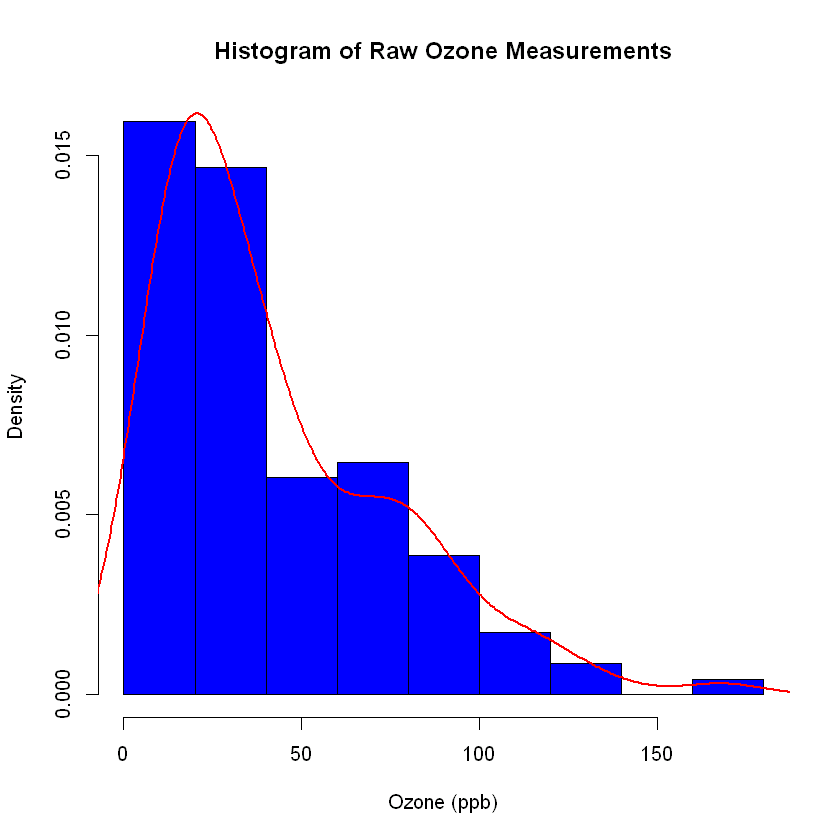

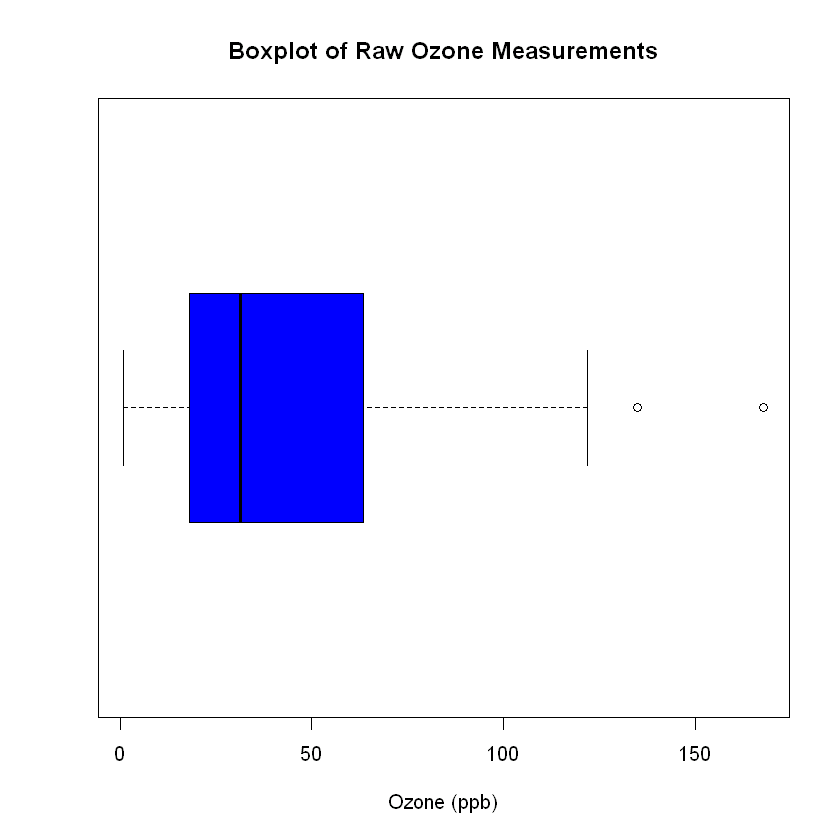

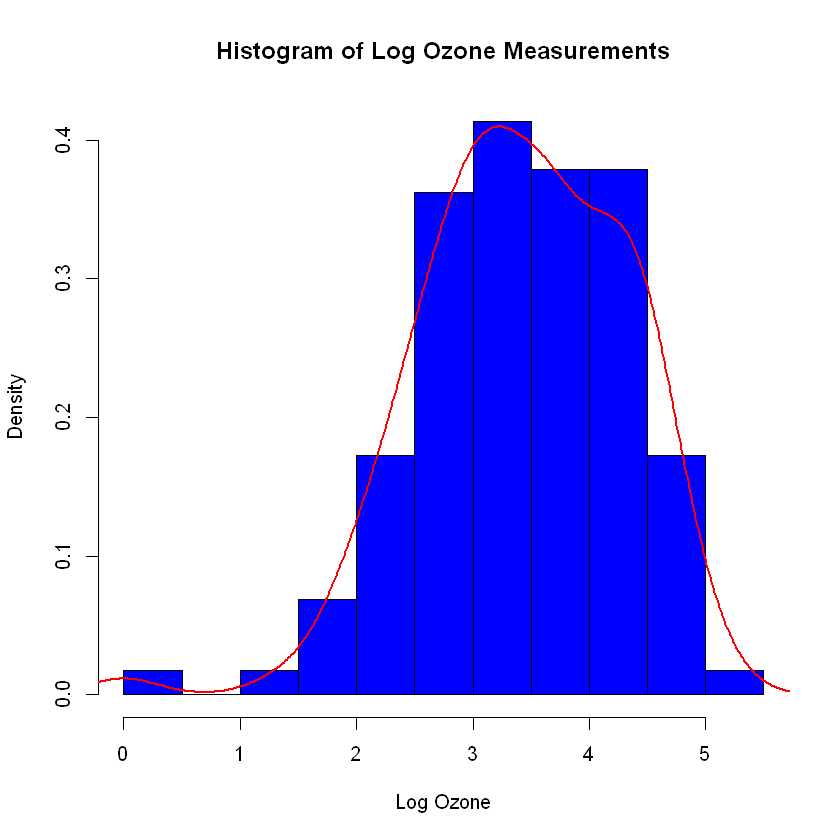

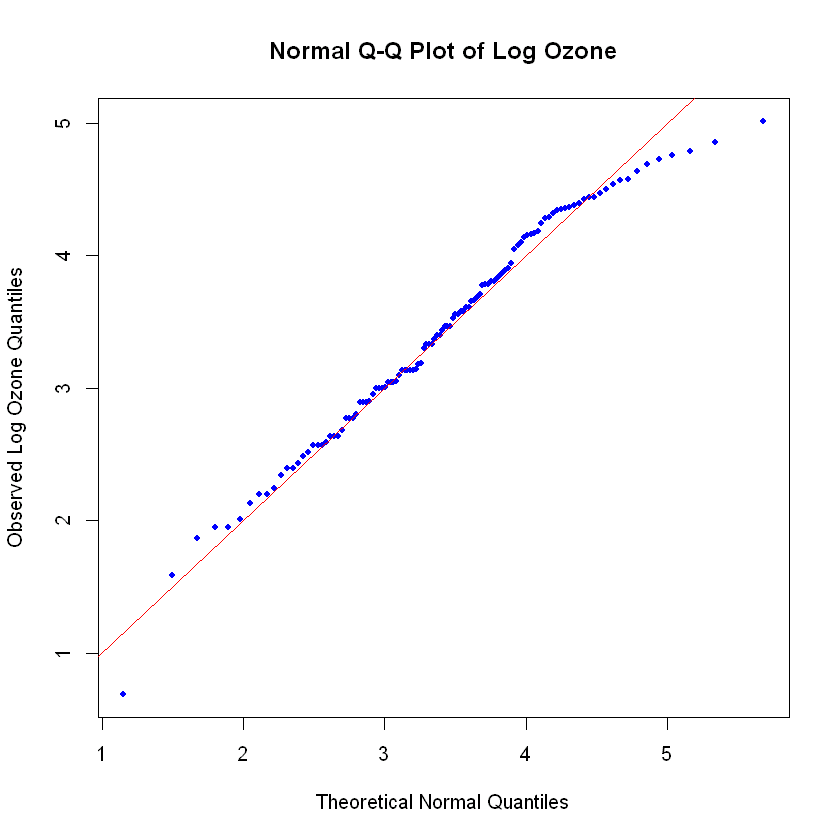

In [122]:
#Read the air quality data first
airQuality <- read.csv("data/airquality.csv")
head(airQuality)
nrow(airQuality)
summary(airQuality$Ozone)
#Check for the number of missing and nonpositive measurements
sum(is.na(airQuality$Ozone))
sum(airQuality$Ozone <= 0, na.rm = TRUE)
#Retain the positive, nonmissing Ozone measurements
ozoneMeasurements <- airQuality$Ozone[!is.na(airQuality$Ozone) & airQuality$Ozone > 0]
length(ozoneMeasurements)
#Calculate how many rows were removed
rowsRemoved <- nrow(airQuality) - length(ozoneMeasurements)
rowsRemoved
#Get descriptive statistics for raw Ozone
summary(ozoneMeasurements)
mean(ozoneMeasurements)
var(ozoneMeasurements)
sd(ozoneMeasurements)
#Create log ozone by taking the natural log of the positive ozone measurements
logOzone <- log(ozoneMeasurements)
summary(logOzone)
mean(logOzone)
var(logOzone)
sd(logOzone)
#Create histogram of raw ozone measurements with density estimate
hist(ozoneMeasurements, probability = TRUE, breaks = 10, main = "Histogram of Raw Ozone Measurements", xlab = "Ozone (ppb)", col = "blue")
lines(density(ozoneMeasurements), col = "red", lwd = 2)
#Create boxplot of raw ozone measurements
boxplot(ozoneMeasurements, horizontal = TRUE, main = "Boxplot of Raw Ozone Measurements", xlab = "Ozone (ppb)", col = "blue")
#Create histogram of log ozone measurements with density estimate
hist(logOzone, probability = TRUE, breaks = 10, main = "Histogram of Log Ozone Measurements", xlab = "Log Ozone", col = "blue")
lines(density(logOzone), col = "red", lwd = 2)
#Create a normal QQ plot of log ozone
numberObs <- length(logOzone)
probPoints <- ppoints(numberObs)
observedQuantiles <- quantile(logOzone, probPoints)
logOzoneMean <- mean(logOzone)
logOzoneSD <- sqrt(mean((logOzone - logOzoneMean)^2))
normalQuantiles <- qnorm(probPoints, mean = logOzoneMean, sd = logOzoneSD)
plot(normalQuantiles, observedQuantiles, main = "Normal Q-Q Plot of Log Ozone", xlab = "Theoretical Normal Quantiles", ylab = "Observed Log Ozone Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)

As shown above, there were originally 153 observations in the dataset. After removing the 37 rows with missing Ozone measurements, 116 positive and nonmissing observations remained. There were no nonpositive Ozone values that needed to be removed. The raw Ozone measurements are strongly right-skewed, with most observations concentrated at lower values and a smaller number of much larger measurements extending the right tail. After taking the natural logarithm, the distribution becomes much more symmetric because the transformation compresses the larger Ozone measurements. The Normal QQ plot of log Ozone follows the reference line reasonably well through most of the distribution, although there are still some deviations in the tails. Therefore, taking logarithms makes the Ozone distribution much closer to Normal, but it does not make it perfectly Normal.


**(b)** Fit Gamma and Lognormal distributions to ozone. Compare parameter estimates, AIC, KS distances, density overlays, and QQ plots. Interpret the Gamma mean and the Lognormal median.


$shape
[1] 1.699563

$rate
[1] 0.04033515

$logLikelyhood
[1] -541.5376

[1] 3.418515

[1] 0.861736

[1] 42.13603

[1] 30.52406

...

[1] 0.08756829

Warning message in ks.test.default(ozoneMeasurements, "plnorm", meanlog = lognormalMeanLog, :
"ties should not be present for the one-sample Kolmogorov-Smirnov test"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  ozoneMeasurements
D = 0.062276, p-value = 0.7592
alternative hypothesis: two-sided


[1] 0.06227592

Model,Parameter1,Parameter2,AIC,KSDistance
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Gamma,1.699563,0.04033515,1087.075,0.08756829
Lognormal,3.418515,0.86173597,1091.766,0.06227592


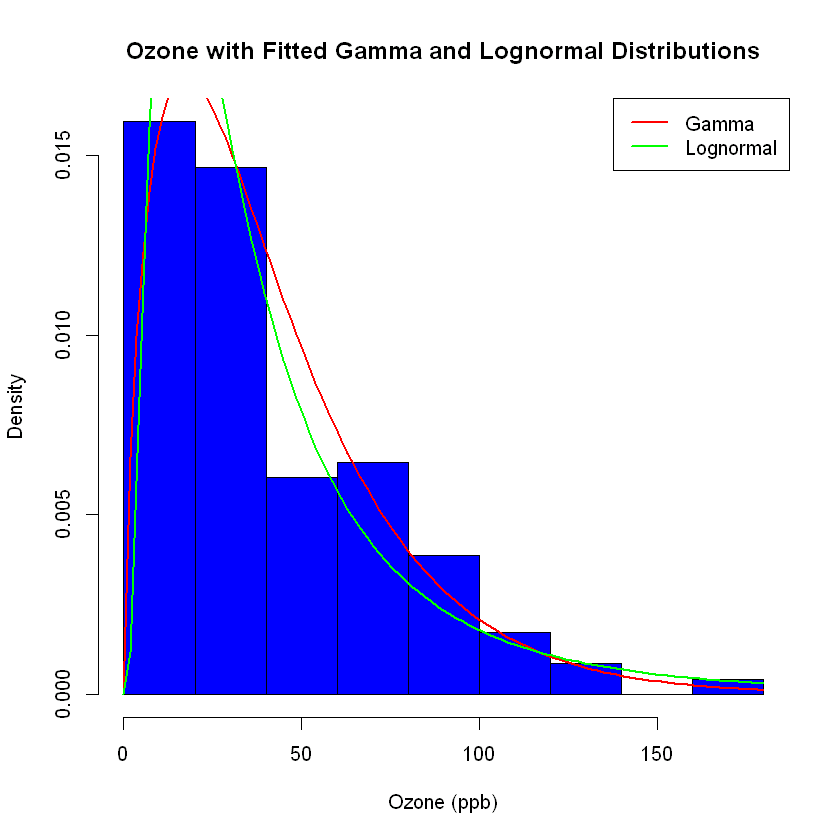

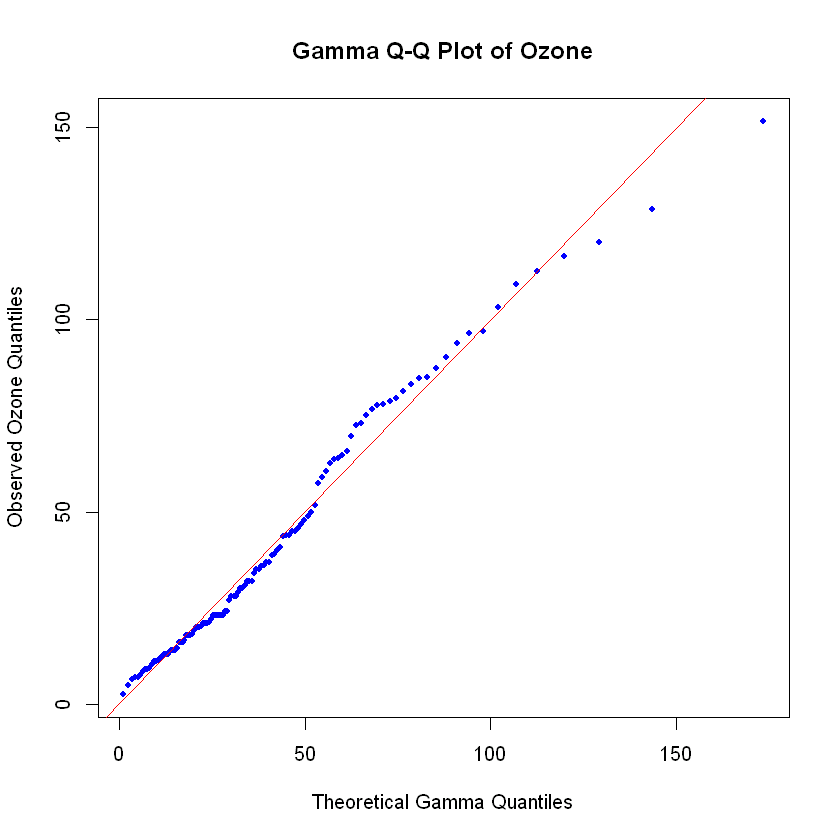

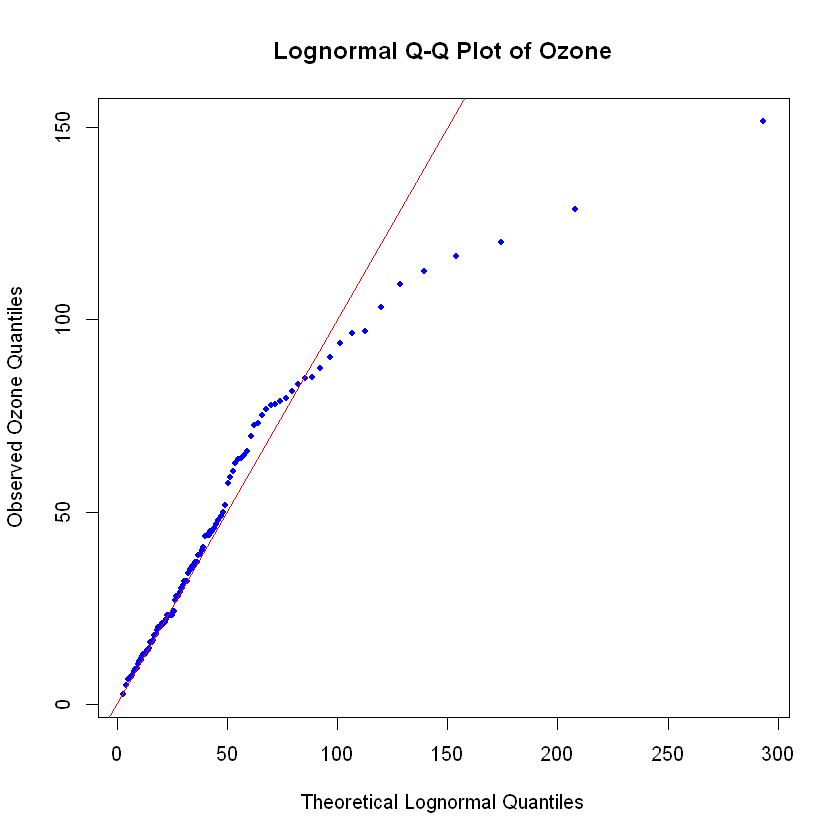

In [123]:
#Fit gamma distribution to the cleaned ozone measurements
fitGamma <- function(x) {
    gammaLogLikelyhood <- function(par) {
        shape <- exp(par[1])
        rate <- exp(par[2])
        -sum(dgamma(x, shape = shape, rate = rate, log = TRUE))
    }
    gammaFit <- optim(
        par = log(c(2, 0.05)),
        fn = gammaLogLikelyhood
    )
    gammaShape <- exp(gammaFit$par[1])
    gammaRate <- exp(gammaFit$par[2])
    logLikelyhoodGamma <- -gammaFit$value
    return(list(
        shape = gammaShape,
        rate = gammaRate,
        logLikelyhood = logLikelyhoodGamma
    ))

}
#Calculate the fitted mean
gammaFit <- fitGamma(ozoneMeasurements)
gammaFit
#Fit lognormal distribution to the ozone measurements
logOzone <- log(ozoneMeasurements)
lognormalMeanLog <- mean(logOzone)
lognormalSDLog <- sqrt(mean((logOzone - lognormalMeanLog)^2))
lognormalMeanLog
lognormalSDLog
#Calculate fitted Gamma mean
gammaMeanLog <- gammaFit$shape / gammaFit$rate
gammaMeanLog
#Calculate the lognormal median
lognormalMedianLog <- exp(lognormalMeanLog)
lognormalMedianLog
#Calculate Gamma AIC
aicGamma <- -2 * gammaFit$logLikelyhood + 2 * 2
aicGamma
#Calculate the lognormal log-likelihood and AIC
logLikelyhoodLogNormal <- sum(
    dlnorm(ozoneMeasurements, 
    meanlog = lognormalMeanLog, 
    sdlog = lognormalSDLog,
    log = TRUE
    )
)
aicLognormal <- -2 * logLikelyhoodLogNormal + 2 * 2
logLikelyhoodLogNormal
aicLognormal
#Calculate the KS distance for fitted Gamma distribution
KSGamma <- ks.test(
    ozoneMeasurements,
    "pgamma",
    shape = gammaFit$shape,
    rate = gammaFit$rate
)
KSGamma
KSdistanceGamma <- as.numeric(KSGamma$statistic)
KSdistanceGamma
#Calculate the KS diatance for fitted Lognormal distribution
KSlogNormal <- ks.test(
    ozoneMeasurements,
    "plnorm",
    meanlog = lognormalMeanLog,
    sdlog = lognormalSDLog
)
KSlogNormal
KSdistancelogNormal <- as.numeric(KSlogNormal$statistic)
KSdistancelogNormal
#Create comparison table for Gamma and Lognormal distributions
fitComparisonTable <- data.frame(
    Model = c("Gamma", "Lognormal"),
    Parameter1 = c(gammaFit$shape, lognormalMeanLog),
    Parameter2 = c(gammaFit$rate, lognormalSDLog),
    AIC = c(aicGamma, aicLognormal),
    KSDistance = c(KSdistanceGamma, KSdistancelogNormal)
)
fitComparisonTable
#Create density overlap for fitted Gamma and Lognormal distribution
hist(
    ozoneMeasurements,
    probability = TRUE,
    breaks = 10,
    main = "Ozone with Fitted Gamma and Lognormal Distributions",
    xlab = "Ozone (ppb)",
    col = "blue"
)
curve(
    dgamma(x, shape = gammaFit$shape, rate = gammaFit$rate),
    add = TRUE,
    col = "red",
    lwd = 2
)
curve(
    dlnorm(x, meanlog = lognormalMeanLog, sdlog = lognormalSDLog),
    add = TRUE,
    col = "green",
    lwd = 2
)
legend(
    "topright",
    legend = c("Gamma", "Lognormal"),
    col = c("red", "green"),
    lwd = 2
)
#Create QQ plot for Gamma
numberObs <- length(ozoneMeasurements)
probPoints <- ppoints(numberObs)
observedQuantiles <- quantile(ozoneMeasurements, probPoints)
gammaQuantiles <- qgamma(
    probPoints,
    shape = gammaFit$shape,
    rate = gammaFit$rate
)
plot(
    gammaQuantiles,
    observedQuantiles,
    main = "Gamma Q-Q Plot of Ozone",
    xlab = "Theoretical Gamma Quantiles",
    ylab = "Observed Ozone Quantiles",
    pch = 16,
    col = "blue",
    cex = 0.7
)
abline(0, 1, col = "red", lwd = 1)
#Create QQ plot for Lognormal
lognormalQuantiles <- qlnorm(
    probPoints,
    meanlog = lognormalMeanLog,
    sdlog = lognormalSDLog
)
plot(
    lognormalQuantiles,
    observedQuantiles,
    main = "Lognormal Q-Q Plot of Ozone",
    xlab = "Theoretical Lognormal Quantiles",
    ylab = "Observed Ozone Quantiles",
    pch = 16,
    col = "blue",
    cex = 0.7
)
abline(0, 1, col = "red", lwd = 1)

The fitted Gamma distribution has shape $\hat{\alpha}\approx 1.6996$ and rate $\hat{\beta}\approx 0.04034$, while the fitted Lognormal distribution has $\hat{\mu}_{\log}\approx 3.4185$ and $\hat{\sigma}_{\log}\approx 0.8617$. The Gamma model has an AIC of approximately 1087.075, compared with approximately 1091.766 for the Lognormal model, so the Gamma model is favored by AIC. However, the Lognormal model has the smaller KS distance, approximately 0.0623 compared with approximately 0.0876 for the Gamma model. The density overlays and QQ plots show that both distributions capture the positive right-skewness of ozone measurements, although both show some departures from the observed data, particularly toward the upper tail. Thus, the diagnostics do not all favor the same model as AIC favors Gamma, whereas the KS distance favors Lognormal. The KS results should be interpreted cautiously because the ozone data contain ties. For the Gamma model, the fitted mean is $\frac{\hat{\alpha}}{\hat{\beta}} = \frac{1.6996}{0.04034} \approx 42.14\text{ ppb}$, meaning that the model's expected ozone concentration is approximately 42.14 ppb. For the Lognormal model, the fitted median is $e^{\hat{\mu}_{\log}} = e^{3.4185} \approx 30.52\text{ ppb}$, meaning that half of the fitted Lognormal distribution lies below approximately 30.52 ppb and half lies above it.


**(c)** Standardize log ozone using its fitted Normal mean and maximum likelihood standard deviation, then square the standardized values. Compare them with a Chi-Squared distribution with 1 degree of freedom using a QQ plot. Identify the observations above its 95th percentile. Explain why this is an approximate diagnostic when the mean and standard deviation are estimated.


[1]  0.3423983  0.1914784 -1.0834043 -0.6128830 -0.1001590 -0.3284311

[1] -1.416302e-16

[1] 1

[1] 0.11723662 0.03666398 1.17376487 0.37562560 0.01003182 0.10786698

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
3.224e-04 1.149e-01 5.618e-01 1.000e+00 1.331e+00 1.574e+01 

[1] 3.841459

[1] 19 21 82

[1] 3

Observation,Ozone,logOzone,StandardizedValue,SquaredStandardizedValue
<int>,<int>,<dbl>,<dbl>,<dbl>
19,1,0.000000,-3.967010,15.737167
21,4,1.386294,-2.358287,5.561518
82,168,5.123964,1.979085,3.916778


CleanedObservation,OriginalRow,Ozone,LogOzone,StandardizedValue,SquaredStandardizedValue
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
19,21,1,0.000000,-3.967010,15.737167
21,23,4,1.386294,-2.358287,5.561518
82,117,168,5.123964,1.979085,3.916778


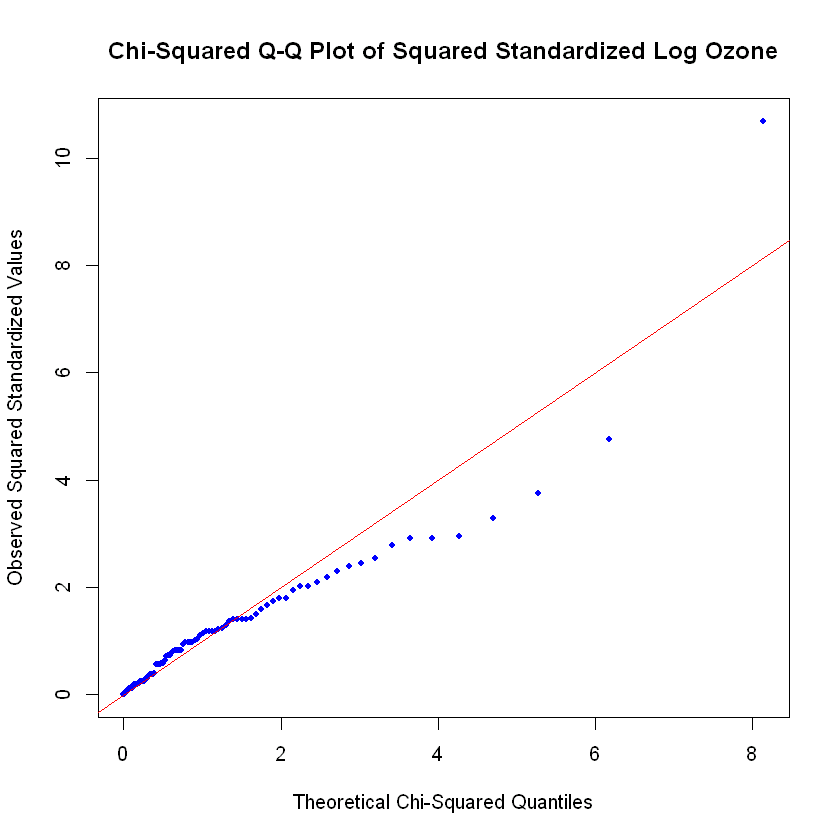

In [124]:
#Standardize log ozone using the fitted Normal mean and MLE standard deviation
standardizeLogOzone <- (logOzone - lognormalMeanLog) / lognormalSDLog
head(standardizeLogOzone)
mean(standardizeLogOzone)
sqrt(mean(standardizeLogOzone^2))
#Square the standardized values
squaredValues <- standardizeLogOzone^2 
head(squaredValues)
summary(squaredValues)
#Make a chi-squared QQ plot for squared standardized log ozone
numberObs <- length(squaredValues)
probPoints <- ppoints(numberObs)
observedChiSquaredQuantiles <- quantile(squaredValues, probPoints)
theoreticalChiSquaredQuantiles <- qchisq(probPoints, df = 1)
plot(theoreticalChiSquaredQuantiles, observedChiSquaredQuantiles, main = "Chi-Squared Q-Q Plot of Squared Standardized Log Ozone", xlab = "Theoretical Chi-Squared Quantiles", ylab = "Observed Squared Standardized Values", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Calculate 95th percentile of Chi-squared distribution with 1 degree of freedom
chiSquared95 <- qchisq(0.95, df = 1)
chiSquared95
#Identify observations that exceed above the 95th percentile
obsAbove95 <- squaredValues > chiSquared95
which(obsAbove95)
sum(obsAbove95)
#Create table of observations above the Chi-Squared 95th percentile
above95Table <- data.frame(
    Observation = which(obsAbove95),
    Ozone = ozoneMeasurements[obsAbove95],
    logOzone = logOzone[obsAbove95],
    StandardizedValue = standardizeLogOzone[obsAbove95],
    SquaredStandardizedValue = squaredValues[obsAbove95]
)
above95Table
#Find original row numbers corresponding to the cleaned ozone measurements
validOzone <- !is.na(airQuality$Ozone) & airQuality$Ozone > 0
originalRows <- which(validOzone)

above95Table <- data.frame(
    CleanedObservation = which(obsAbove95),
    OriginalRow = originalRows[obsAbove95],
    Ozone = ozoneMeasurements[obsAbove95],
    LogOzone = logOzone[obsAbove95],
    StandardizedValue = standardizeLogOzone[obsAbove95],
    SquaredStandardizedValue = squaredValues[obsAbove95]
)

above95Table

As shown above, log ozone was standardized using its fitted Normal mean and maximum likelihood standard deviation, and the standardized values were squared. The squared standardized values were compared with a $\chi^2$ distribution with 1 degree of freedom. The 95th percentile of $\chi_1^2$ is approximately 3.8415. 3 observations exceeded this threshold: original rows 21, 23, and 117 of the dataset, with ozone measurements of 1, 4, and 168 ppb, respectively. Their squared standardized values were approximately 15.7372, 5.5615, and 3.9168. Thus, the diagnostic identifies unusually extreme observations on both the lower and upper sides of the fitted log-Normal model. The QQ plot follows the reference reasonably well over part of the distribution but shows departures, particularly toward the upper tail. This is an approximate diagnostic because the Normal mean and standard deviation used in the standardization were estimated from the same data. If the true population parameters $\mu$ and $\sigma$ were known, then $Z = \frac{Y - \mu}{\sigma}$ would follow a standard Normal distribution under the model, so $Z^2$ would follow $\chi_1^2$. Replacing $\mu$ and $\sigma$ with estimates from the sample means that the standardized observations are not exact independent $N(0, 1)$ variables. Therefore, their squared values do not follow an exact $\chi_1^2$ distribution, making this an approximate diagnostic.


**(d)** Estimate $P(\mathrm{Ozone}>70)$ and $P(\mathrm{Ozone}\leq20)$ under both models. Compare these with the empirical proportions. Explain which population these data can reasonably describe and how missing readings might affect the comparison.


In [139]:
#Estimate P(Ozone > 70) under the fitted gamma model
gammaProbAbove70 <- 1 - pgamma(70, shape = gammaFit$shape, rate = gammaFit$rate)
gammaProbAbove70
#Eestimate P(Ozone <= 20) under the fitted gamma model
gammaProbBelow20 <- pgamma(20, shape = gammaFit$shape, rate = gammaFit$rate)
gammaProbBelow20
#Estimate P(Ozone > 70) under the fitted lognormal model
lognormalProbAbove70 <- 1 - plnorm(70, meanlog = lognormalMeanLog, sdlog = lognormalSDLog)
lognormalProbAbove70
#Estimate P(Ozone <= 20) under the fitted lognormal model
lognormalProbBelow20 <- plnorm(20, meanlog = lognormalMeanLog, sdlog = lognormalSDLog)
lognormalProbBelow20
#Calculate empirical proportions from observed ozone measurements
empiricalAbove70 <- mean(ozoneMeasurements > 70)
empiricalBelow20 <- mean(ozoneMeasurements <= 20)
empiricalAbove70
empiricalBelow20
#Find number of observations satisfying each condition
sum(ozoneMeasurements > 70)
sum(ozoneMeasurements <= 20)
length(ozoneMeasurements)
#Create comparison tables of model probabilities and empirical proportions
probComparisonTable <- data.frame(
    Probability = c("P(Ozone > 70)", "P(Ozone <= 20)"),
    Gamma = c(gammaProbAbove70, gammaProbBelow20),
    Lognormal = c(lognormalProbAbove70, lognormalProbBelow20),
    Empirical = c(empiricalAbove70, empiricalBelow20)
)
probComparisonTable

[1] 0.166035

[1] 0.2762755

[1] 0.1677364

[1] 0.3118485

[1] 0.2155172

[1] 0.3189655

[1] 25

[1] 37

[1] 116

Probability,Gamma,Lognormal,Empirical
<chr>,<dbl>,<dbl>,<dbl>
P(Ozone > 70),0.1660350,0.1677364,0.2155172
P(Ozone <= 20),0.2762755,0.3118485,0.3189655


As shown under the fitted Gamma model, the estimated probability that ozone exceeds 70 ppb is approximately 0.1660, while the fitted Lognormal model gives approximately 0.1677. The empirical proportion is approximately 0.2155, so both models underestimate the observed proportion above 70 ppb. For ozone measurements at or below 20 ppb, the Gamma model gives approximately 0.2763 and the Lognormal model gives approximately 0.3118, compared with the empirical proportion being approximately 0.3190. Thus, the Lognormal model is particularly close to the empirical proportion for the lower threshold. These results describe the population represented by the ozone measurements in this dataset rather than ozone concentrations in all locations or time periods. The analysis uses only the 116 positive, nonmissing ozone measurements after 37 rows with missing ozone values were removed. If the missing ozone readings are systematically related to ozone concentration, then the retained observations may not be representative of all readings, which could affect both the fitted model probabilities and empirical proportions.


**(e)** Fit a Pareto model to ozone values at or above the sample 80th percentile and repeat at the 90th percentile. For each threshold $u$, use $\widehat\alpha=m/\sum_{j=1}^{m}\log(x_j/u)$, where $m$ is the number of retained tail observations. Report $u$, $m$, and $\widehat\alpha$, make Pareto QQ plots, and estimate $P(X>150\mid X\geq u)$. The Pareto quantile is $u(1-p)^{-1/\alpha}$. Discuss sensitivity to the threshold. Do not compare AIC values computed on different tail samples.


[1] 73

[1] 87

[1] 115 135  77  97  97  85  79  80 108  82  78 122  89 110 168  73  76 118  84
[20]  85  96  78  73  91

[1] 115 135  97  97 108 122  89 110 168 118  96  91

[1] 24

[1] 12

[1] 4.056167

[1] 4.204836

[1] 0.0538715

[1] 0.101217

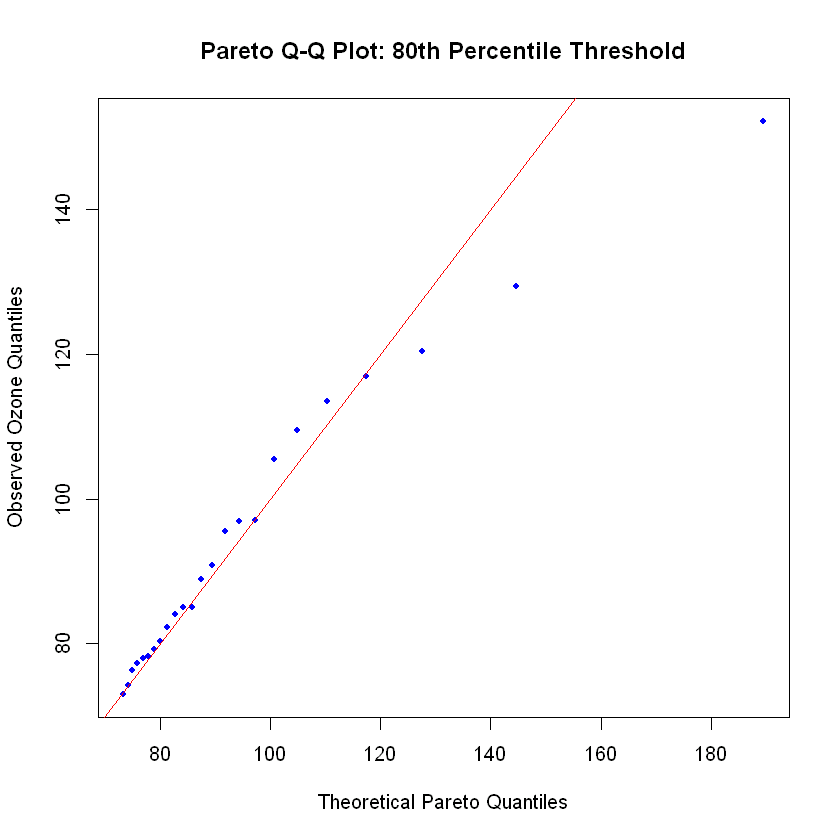

Threshold,u,m,AlphaHat,ProbAbove150
<chr>,<dbl>,<int>,<dbl>,<dbl>
80th Percentile,73,24,4.056167,0.0538715
90th Percentile,87,12,4.204836,0.1012170


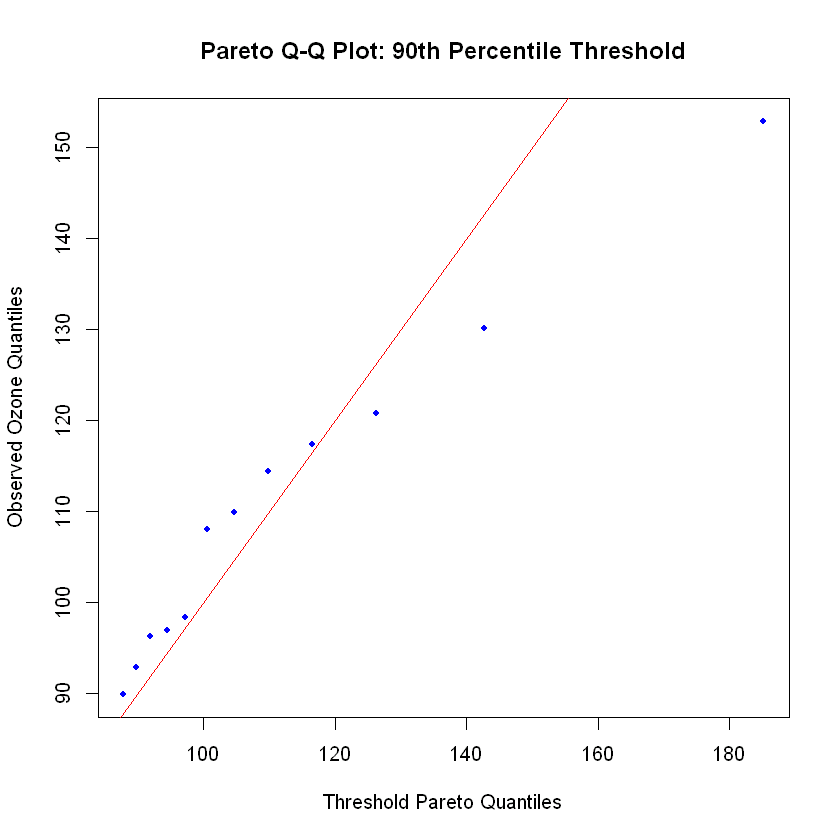

In [148]:
#Find the 80th and 90th percentile thresholds
u80 <- as.numeric(quantile(ozoneMeasurements, 0.80))
u90 <- as.numeric(quantile(ozoneMeasurements, 0.90))
u80
u90
#Keep ozone values at or above both 80th and 90th percentile thresholds
tail80 <- ozoneMeasurements[ozoneMeasurements >= u80]
tail90 <- ozoneMeasurements[ozoneMeasurements >= u90]
tail80
tail90
#Find the number of retained tail observations
m80 <- length(tail80)
m90 <- length(tail90)
m80
m90
#Estimate Pareto alpha for the 80th percentile threshold 
alphaHat80 <- m80 / sum(log(tail80 / u80))
alphaHat90 <- m90 / sum(log(tail90 / u90))
alphaHat80
alphaHat90
#Estimate P(X > 150 | X >= u) for each threshold
probAbove150For80 <- (u80/150)^alphaHat80
probAbove150For90 <- (u90/150)^alphaHat90
probAbove150For80
probAbove150For90
#Create Pareto QQ plot for the 80th percentile threshold
probPoints80 <- ppoints(m80)
observedQuantiles80 <- quantile(tail80, probPoints80)
paretoQuantiles80 <- u80 * (1 - probPoints80)^(-1 / alphaHat80)
plot(paretoQuantiles80, observedQuantiles80, main = "Pareto Q-Q Plot: 80th Percentile Threshold", xlab = "Theoretical Pareto Quantiles", ylab = "Observed Ozone Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Create Pareto QQ plot for the 90th percentile threshold
probPoints90 <- ppoints(m90)
observedQuantiles90 <- quantile(tail90, probPoints90)
paretoQuantiles90 <- u90 * (1 - probPoints90)^(-1 / alphaHat90)
plot(paretoQuantiles90, observedQuantiles90, main = "Pareto Q-Q Plot: 90th Percentile Threshold", xlab = "Threshold Pareto Quantiles", ylab = "Observed Ozone Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Make a final Pareto Comparison Table
paretoComparisonTable <- data.frame(
    Threshold = c("80th Percentile", "90th Percentile"),
    u = c(u80, u90),
    m = c(m80, m90),
    AlphaHat = c(alphaHat80, alphaHat90),
    ProbAbove150 = c(probAbove150For80, probAbove150For90)
)
paretoComparisonTable


Using the sample 80th percentile gives a threshold of $u = 73$ and $m = 24$ tail observations and producing $\hat{\alpha}\approx 4.0562$. The estimated conditional probability is $P(X > 150 \mid X \geq 73) \approx 0.0539$. Using the sample 90th percentile gives $u = 87$, retaining $m = 12$ observations and producing $\hat{\alpha}\approx 4.2048$, with $P(X > 150 \mid X \geq 87) \approx 0.1012$. The estimated shape parameter changes only moderately between the two thresholds, from approximately 4.06 to 4.20. However, increasing the threshold reduces the tail sample size from 24 to 12 observations, making the higher-threshold estimate more sensitive to individual extreme observations. The conditional exceedance probability also changes from approximately 5.39% to 10.12%, although these probabilities are conditioned on different thresholds and therefore should not be interpreted as directly comparable unconditional probabilities. The QQ plots show some departures from the fitted Pareto models, particularly among the largest observations. With that being said, AIC values should not be compared between these two Pareto fits because the models are fitted to different tail samples. 


## Question 5
### Other real measurements

Use `insect_sprays.csv`, `precipitation.csv`, `airquality.csv`, and `iris.csv`. Keep the datasets separate because their rows represent different observational units.


**(a)** Describe the unit of observation and the support of the measured variable in the insect and precipitation data. Make a plot for each. Explain why counts and positive amounts call for different distribution families. The precipitation values are city averages over 1941 to 1970, not observations from individual years.


,count,spray
,<int>,<chr>
1,10,A
2,7,A
3,20,A
4,14,A
5,14,A
6,12,A


,city,annual_inches
,<chr>,<dbl>
1,Mobile,67.0
2,Juneau,54.7
3,Phoenix,7.0
4,Little Rock,48.5
5,Los Angeles,14.0
6,Sacramento,17.2


'data.frame':	72 obs. of  2 variables:
 $ count: int  10 7 20 14 14 12 10 23 17 20 ...
 $ spray: chr  "A" "A" "A" "A" ...


[1] 72  2

'data.frame':	70 obs. of  2 variables:
 $ city         : chr  "Mobile" "Juneau" "Phoenix" "Little Rock" ...
 $ annual_inches: num  67 54.7 7 48.5 14 17.2 20.7 13 43.4 40.2 ...


...

[1] 7.203286

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   7.00   29.38   36.60   34.89   42.77   67.00 

[1] 34.88571

[1] 187.8723

[1] 13.70665

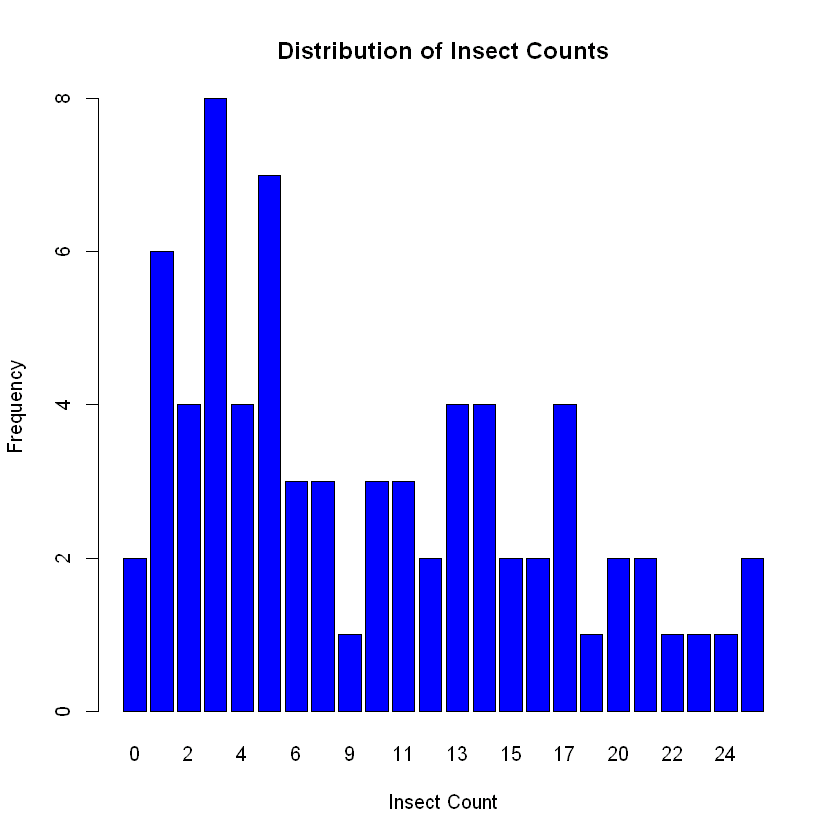

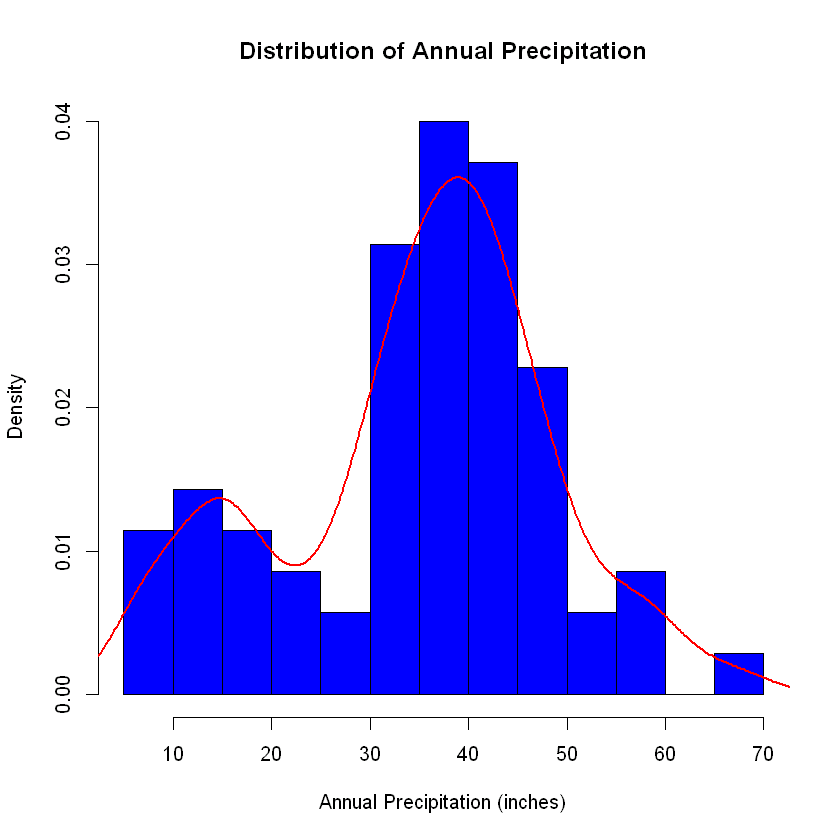

In [22]:
#Read the insect sprays and precipitation datasets
insectSprays <- read.csv("data/insect_sprays.csv")
precipitation <- read.csv("data/precipitation.csv")
#Look at the first few rows of each dataset
head(insectSprays)
head(precipitation)
#Check the structure and dimensions of each dataset
str(insectSprays)
dim(insectSprays)
str(precipitation)
dim(precipitation)
#Create vectors for measured variables
insectCount <- insectSprays$count
annualPrecipitation <- precipitation$annual_inches
#Get descriptive statistics for insect counts
summary(insectCount)
mean(insectCount)
var(insectCount)
sd(insectCount)
#Get descriptive statistics for annual precipitation
summary(annualPrecipitation)
mean(annualPrecipitation)
var(annualPrecipitation)
sd(annualPrecipitation)
#Create a frequency plot of insect counts
insectCountFrequency <- table(insectCount)
barplot(insectCountFrequency, main = "Distribution of Insect Counts", xlab = "Insect Count", ylab = "Frequency", col = "blue")
#Create a histogram for annual precipitation 
hist(annualPrecipitation, probability = TRUE, breaks = 10, main = "Distribution of Annual Precipitation", xlab = "Annual Precipitation (inches)", ylab = "Density", col = "blue")
lines(density(annualPrecipitation), col = "red", lwd = 2)

For the insect spray data, each observation represents an experimental unit receiving one of the insecticide spray treatments, and count is the observed number of insects. The support of the count variable is the set of nonnegative integers. Because counts are discrete, a discrete count distribution family, such as the Poisson family, is appropriate rather than a continuous distribution. For the precipitation data, each observation represents a city, and annual_inches is that city's average annual precipitation over 1941–1970. Thus, these observations are city averages rather than measurements from individual years. The variable is a positive continuous amount with support $x > 0$. Therefore, positive continuous distribution families, such as Gamma or Lognormal distributions, are more appropriate candidates than discrete count distributions. The two variables require different distribution families because insect counts can take only nonnegative integer values, whereas precipitation can take continuous positive values.


**(b)** Fit a Poisson model to all insect counts and another to Spray A alone. Report means, variances, variance to mean ratios, and fitted probabilities of a count above 12. Plot observed and expected frequencies for each sample. Explain what pooling treatments does to the interpretation.


[1] 72

[1] 12

[1] 10  7 20 14 14 12 10 23 17 20 14 13 11 17 21 11 16 14 17 17 19 21  7 13  0
[26]  1  7  2  3  1  2  1  3  0  1  4  3  5 12  6  4  3  5  5  5  5  2  4  3  5
[51]  3  5  3  6  1  1  3  2  6  4 11  9 15 22 15 16 13 10 26 26 24 13

[1] 10  7 20 14 14 12 10 23 17 20 14 13

[1] 9.5

...

[1] 0.1635703

[1] 0.6889178

Sample,NumberObs,Mean,Variance,VarMeanRatio,LambdaHat,ProbAbove12
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
All Insect Counts,72,9.5,51.88732,5.461824,9.5,0.1635703
Spray A,12,14.5,22.27273,1.536050,14.5,0.6889178


Count,Observed,Expected
<int>,<dbl>,<dbl>
0,2,0.0053893318
1,6,0.0511986516
2,4,0.2431935953
3,8,0.7701130518
4,4,1.8290184980
5,7,3.4751351462
6,3,5.5022973149
7,3,7.4674034988
8,0,8.8675416548


Count,Observed,Expected
<int>,<dbl>,<dbl>
0,0,6.052172e-06
1,0,8.775649e-05
2,0,6.362346e-04
3,0,3.075134e-03
4,0,1.114736e-02
5,0,3.232734e-02
6,0,7.812441e-02
7,1,1.618291e-01
8,0,2.933153e-01


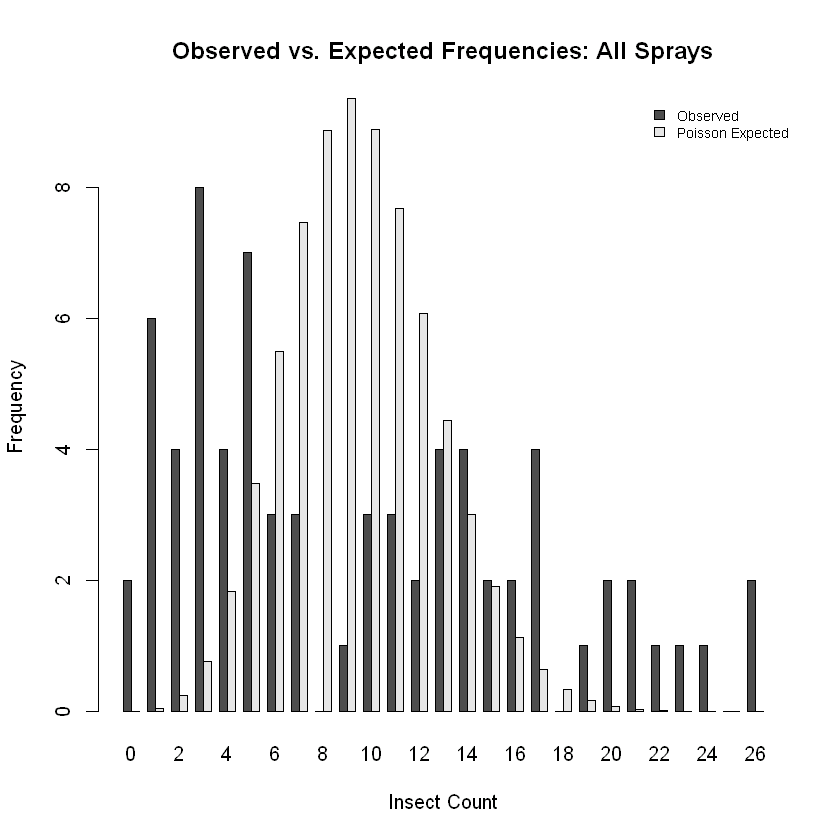

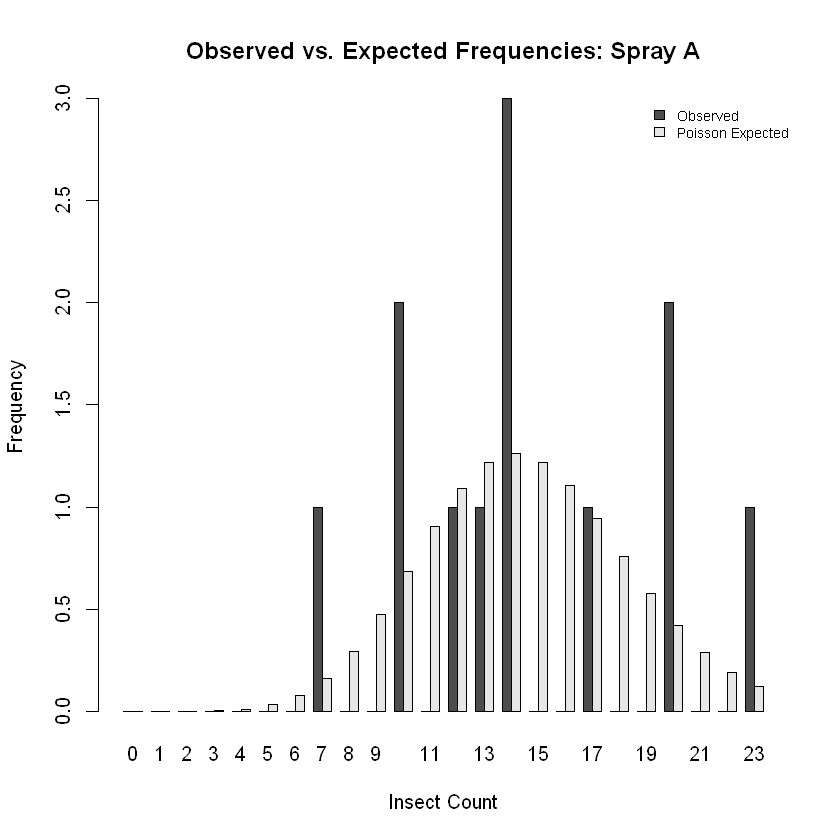

In [27]:
#Create samples for all insect counts and Spray A insect counts 
allInsectCounts <- insectSprays$count
sprayACounts <- insectSprays$count[insectSprays$spray == "A"]
length(allInsectCounts)
length(sprayACounts)
allInsectCounts
sprayACounts
#Calculate means and variances in each samples
meanAll <- mean(allInsectCounts)
meanSprayA <- mean(sprayACounts)
meanAll
meanSprayA
varAll <- var(allInsectCounts)
varSprayA <- var(sprayACounts)
varAll
varSprayA
#Calculate variance to mean ratios
varMeanRatioAll <- varAll / meanAll
varMeanRatioSprayA <- varSprayA / meanSprayA
varMeanRatioAll
varMeanRatioSprayA
#Fit Poisson models using sample means
lambdaAll <- meanAll
lambdaSprayA <- meanSprayA
lambdaAll
lambdaSprayA
#Calculate fitted probabilities of a count above 12
probAbove12All <- 1 - ppois(12, lambda = lambdaAll)
probAbove12SprayA <- 1 - ppois(12, lambda = lambdaSprayA)
probAbove12All
probAbove12SprayA
#Create comparison table between all insect counts and spray A
poissonComparisonTable <- data.frame(
    Sample = c("All Insect Counts", "Spray A"),
    NumberObs = c(length(allInsectCounts), length(sprayACounts)),
    Mean = c(meanAll, meanSprayA),
    Variance = c(varAll, varSprayA),
    VarMeanRatio = c(varMeanRatioAll, varMeanRatioSprayA),
    LambdaHat = c(lambdaAll, lambdaSprayA),
    ProbAbove12 = c(probAbove12All, probAbove12SprayA)
)
poissonComparisonTable
#Create observed and expected frequencies for all insect counts
kAll <- 0:max(allInsectCounts)

observedAll <- as.numeric(
    table(factor(allInsectCounts, levels = kAll))
)

expectedAll <- length(allInsectCounts) * dpois(
    kAll,
    lambda = lambdaAll
)

frequencyTableAll <- data.frame(
    Count = kAll,
    Observed = observedAll,
    Expected = expectedAll
)

frequencyTableAll
barplot(
    rbind(
        frequencyTableAll$Observed,
        frequencyTableAll$Expected
    ),
    beside = TRUE,
    names.arg = frequencyTableAll$Count,
    xlab = "Insect Count",
    ylab = "Frequency",
    main = "Observed vs. Expected Frequencies: All Sprays",
    legend.text = c("Observed", "Poisson Expected"),
    args.legend = list(
        x = "topright",
        cex = 0.7,
        bty = "n"
    )
)
#Create observed and expected frequencies for Spray A 
kSprayA <- 0:max(sprayACounts)
observedSprayA <- as.numeric(
    table(factor(sprayACounts, levels = kSprayA))
)
expectedSprayA <- length(sprayACounts) * dpois(
    kSprayA,
    lambda = lambdaSprayA
)
frequencyTableSprayA <- data.frame(
    Count = kSprayA,
    Observed = observedSprayA,
    Expected = expectedSprayA
)
frequencyTableSprayA
barplot(
    rbind(
        frequencyTableSprayA$Observed,
        frequencyTableSprayA$Expected
    ),
    beside = TRUE,
    names.arg = frequencyTableSprayA$Count,
    xlab = "Insect Count",
    ylab = "Frequency",
    main = "Observed vs. Expected Frequencies: Spray A",
    legend.text = c("Observed", "Poisson Expected"),
    args.legend = list(
        x = "topright",
        cex = 0.7,
        bty = "n"
    )
)

For all 72 insect counts, the sample mean is 9.50, the sample variance is approximately 51.887, and the variance -to-mean ratio is approximately 5.462. The fitted Poisson model estimates $\hat{\lambda} = 9.50$, giving $P(X > 12)\approx 0.164$. The variance is substantially larger than the mean, indicating considerable overdispersion relative to the Poisson assumption. The observed and expected frequency plot also shows noticeable differences between the pooled data and the fitted Poisson frequencies. For Spray A alone, the sample mean is 14.50 and the sample variance is approximately 22.27, producing a variance-to-mean ratio of approximately 1.54. This is considerably closer to the Poisson expectation of 1 than the ratio for the pooled sample, although some overdispersion is still present. The fitted Spray A model has $\hat{\lambda} = 14.50$ and estimates $P(X > 12)\approx 0.689$. The Spray A sample is still somewhat more variable than an ideal Poisson model, but its variance-to-mean ratio is much closer to 1 than that of the pooled data. Pooling all spray treatments ignores differences among the treatments and treats their observations as though they came from a single population with one common Poisson rate. If the sprays produce different typical insect counts, combining them introduces between-treatment variation in addition to within-treatment variation. This helps explain the substantial overdispersion in the pooled sample. The Spray A model instead describes counts under one particular treatment and therefore has a different interpretation.


**(c)** Fit Gamma and Lognormal distributions to the precipitation values. Compare AIC and QQ plots, interpret the fitted parameters, and estimate the probability that a location's average annual precipitation exceeds 50 inches. Explain why this is not the probability of a wet year at one city.


[1] 70

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   7.00   29.38   36.60   34.89   42.77   67.00 

$shape
[1] 4.716202

$rate
[1] 0.1351898

$logLikelihood
[1] -288.4646

[1] 34.88578

[1] 3.442351

...

[1] 35.87337

[1] 580.9293

[1] -295.1425

[1] 594.2851

Model,Parameter1,Parameter2,AIC
<chr>,<dbl>,<dbl>,<dbl>
Gamma,4.716202,0.1351898,580.9293
Lognormal,3.442351,0.5246796,594.2851


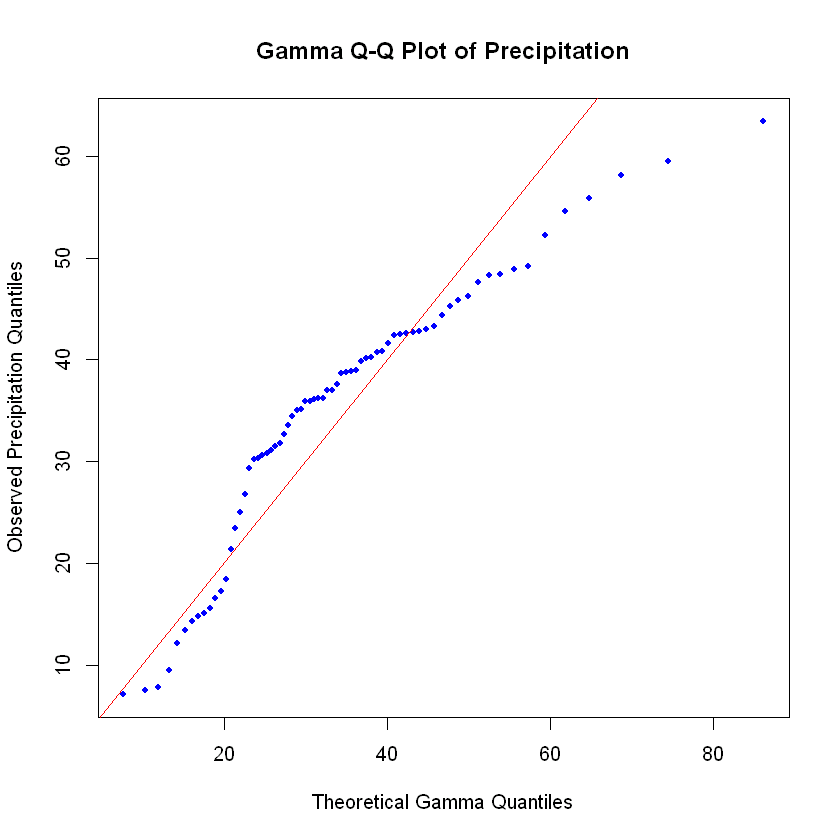

[1] 0.1633174

[1] 0.1853508

Model,ProbAbove50
<chr>,<dbl>
Gamma,0.1633174
Lognormal,0.1853508


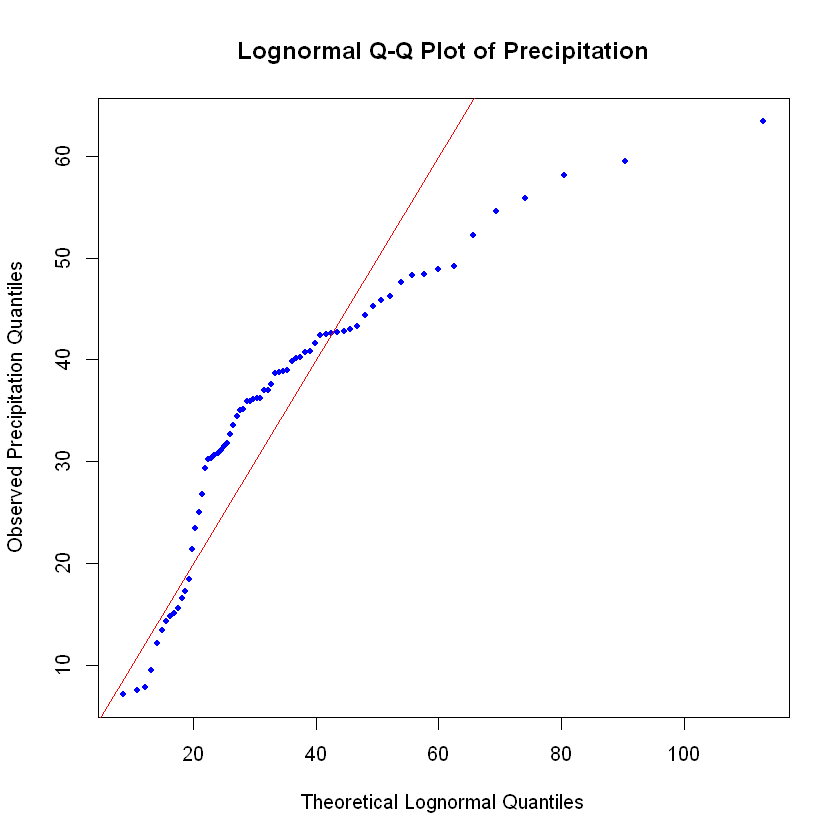

In [42]:
#Create vector of annual precipitation values
precipitationValues <- precipitation$annual_inches
length(precipitationValues)
summary(precipitationValues)
#fit Gamma distribution to precipitation values
fitGammaPrecipitation <- function(x) {
    gammaLogLikelihood <- function(par) {
        shape <- exp(par[1])
        rate <- exp(par[2])

        -sum(
            dgamma(
                x, 
                shape = shape,
                rate = rate,
                log = TRUE
            )
        )
    }
    gammaFit <- optim(
        par = log(c(2, 0.05)),
        fn = gammaLogLikelihood
    )
    gammaShape <- exp(gammaFit$par[1])
    gammaRate <- exp(gammaFit$par[2])
    logLikelihoodGamma <- -gammaFit$value

    return(
        list(
            shape = gammaShape,
            rate = gammaRate,
            logLikelihood = logLikelihoodGamma
        )
    )
}

gammaPrecipitationFit <- fitGammaPrecipitation(precipitationValues)
gammaPrecipitationFit
#Calculate fitted gamma mean
gammaPrecipitationMean <- gammaPrecipitationFit$shape / gammaPrecipitationFit$rate
gammaPrecipitationMean
#Fit lognormal distribution to precipitation values
logPrecipitation <- log(precipitationValues)
lognormalPrecipitationMeanLog <- mean(logPrecipitation)
lognormalPrecipitationSDLog <- sqrt(mean((logPrecipitation - lognormalPrecipitationMeanLog)^2))
lognormalPrecipitationMeanLog
lognormalPrecipitationSDLog
#Calculate fitted lognormal median
lognormalPrecipitationMedian <- exp(lognormalPrecipitationMeanLog)
lognormalPrecipitationMedian
#Calculated fitted lognormal mean
lognormalPrecipitationMean <- exp(lognormalPrecipitationMeanLog + lognormalPrecipitationSDLog^2 / 2)
lognormalPrecipitationMean
#Calculate AIC values for both gamma and lognormal
aicGammaPrecipitation <- -2 * gammaPrecipitationFit$logLikelihood + 2 * 2
aicGammaPrecipitation
#Calculate lognormal log-likelihood and AIC
logLikelihoodLognormalPrecipitation <- sum(
    dlnorm(
        precipitationValues,
        meanlog = lognormalPrecipitationMeanLog,
        sdlog = lognormalPrecipitationSDLog,
        log = TRUE
    )
)
logLikelihoodLognormalPrecipitation
aicLognormalPrecipitation <- -2 * logLikelihoodLognormalPrecipitation + 2 * 2
aicLognormalPrecipitation
#Create comparison table between gamma and lognormal
precipitationFitComparison <- data.frame(
    Model = c("Gamma", "Lognormal"),
    Parameter1 = c(gammaPrecipitationFit$shape, lognormalPrecipitationMeanLog),
    Parameter2 = c(gammaPrecipitationFit$rate, lognormalPrecipitationSDLog),
    AIC = c(aicGammaPrecipitation, aicLognormalPrecipitation)
)
precipitationFitComparison
#Create Gamma QQ plot 
numberPrecipitationObs <- length(precipitationValues)
precipitationProbPoints <- ppoints(numberPrecipitationObs)
observedPrecipitationQuantiles <- quantile(precipitationValues, precipitationProbPoints)
gammaPrecipitationQuantiles <- qgamma(precipitationProbPoints, shape = gammaPrecipitationFit$shape, rate = gammaPrecipitationFit$rate)
plot(gammaPrecipitationQuantiles, observedPrecipitationQuantiles, main = "Gamma Q-Q Plot of Precipitation", xlab = "Theoretical Gamma Quantiles", ylab = "Observed Precipitation Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Create Lognormal QQ plot
lognormalPrecipitationQuantiles <- qlnorm(precipitationProbPoints, meanlog = lognormalPrecipitationMeanLog, sdlog = lognormalPrecipitationSDLog)
plot(lognormalPrecipitationQuantiles, observedPrecipitationQuantiles, main = "Lognormal Q-Q Plot of Precipitation", xlab = "Theoretical Lognormal Quantiles", ylab = "Observed Precipitation Quantiles", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)
#Calculate probability precipitation exceeds 50 inches under Gamma model
probAbove50Gamma <- 1 - pgamma(50, shape = gammaPrecipitationFit$shape, rate = gammaPrecipitationFit$rate)
probAbove50Gamma
probAbove50Lognormal <- 1 - plnorm(50, meanlog = lognormalPrecipitationMeanLog, sdlog = lognormalPrecipitationSDLog)
probAbove50Lognormal
#Make a final probability comparison between both gamma and lognormal
precipitationProbabilityTable <- data.frame(
    Model = c("Gamma", "Lognormal"),
    ProbAbove50 = c(probAbove50Gamma, probAbove50Lognormal)
)
precipitationProbabilityTable

The fitted Gamma distribution has a shape parameter of approximately 4.7162 and approximately a rate parameter of 0.1352. Its fitted mean is approximately 34.89 inches, which is nearly identical to the observed sample mean. The fitted Lognormal distribution has $\hat{\mu}\approx 3.4424$ and $\hat{\sigma}\approx 0.5247$ on the log scale. Its fitted median is approximately 31.26 inches and its fitted mean is approximately 35.87 inches. The Gamma model has an AIC of approximately 580.93, compared with 594.29 for the Lognormal model. Therefore, the Gamma model is favored by AIC. The QQ plots also show that neither model fits the precipitation data perfectly, but the Gamma model generally provides the better fit of the two, while the Lognormal QQ plot displays stronger systematic departures from the reference line.
Under the Gamma model, the estimated probability that a location's average annual precipitation exceeds 50 inches is approximately 0.1633 or 16.33%. Under the Lognormal model, the estimated probability is approximately 0.1854 or 18.54%. These probabilities describe variation across locations' long-term average annual precipitation, not the probability that a particular city experiences a wet year. Each precipitation observation represents a city's average annual precipitation over 1941–1970 rather than precipitation recorded during an individual year. Therefore, the fitted distributions describe differences in long-term precipitation averages among locations, not year-to-year variation within one city.


**(d)** From the air quality data, calculate gaps in calendar days between consecutive recorded ozone readings of at least 70. Keep a gap only if every day from its first endpoint to its second has an observed ozone reading. Report how many gaps you exclude. Plot the retained gaps. Fit a Geometric model to gap minus one and an Exponential approximation to the gaps. Compare their fitted means and probabilities of a gap of at most 2 days with the observed values. Explain why AIC from a discrete probability mass and a continuous density should not be compared, and discuss the effects of missing readings and seasonality.


,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


'data.frame':	153 obs. of  6 variables:
 $ Ozone  : int  41 36 12 18 NA 28 23 19 8 NA ...
 $ Solar.R: int  190 118 149 313 NA NA 299 99 19 194 ...
 $ Wind   : num  7.4 8 12.6 11.5 14.3 14.9 8.6 13.8 20.1 8.6 ...
 $ Temp   : int  67 72 74 62 56 66 65 59 61 69 ...
 $ Month  : int  5 5 5 5 5 5 5 5 5 5 ...
 $ Day    : int  1 2 3 4 5 6 7 8 9 10 ...


[1] 153   6

,Date,Month,Day,Ozone
,<date>,<int>,<int>,<int>
1,1973-05-01,5,1,41
2,1973-05-02,5,2,36
3,1973-05-03,5,3,12
4,1973-05-04,5,4,18
5,1973-05-05,5,5,NA
6,1973-05-06,5,6,28


[1]  30  40  62  68  69  70  71  80  85  86  89  96  99 100 101 117 118 120 121
[20] 122 123 124 125 126 127

...

[1] 0.6296296

[1] 1.588235

[1] 0.8628258

[1] 0.7161358

[1] 0.8235294

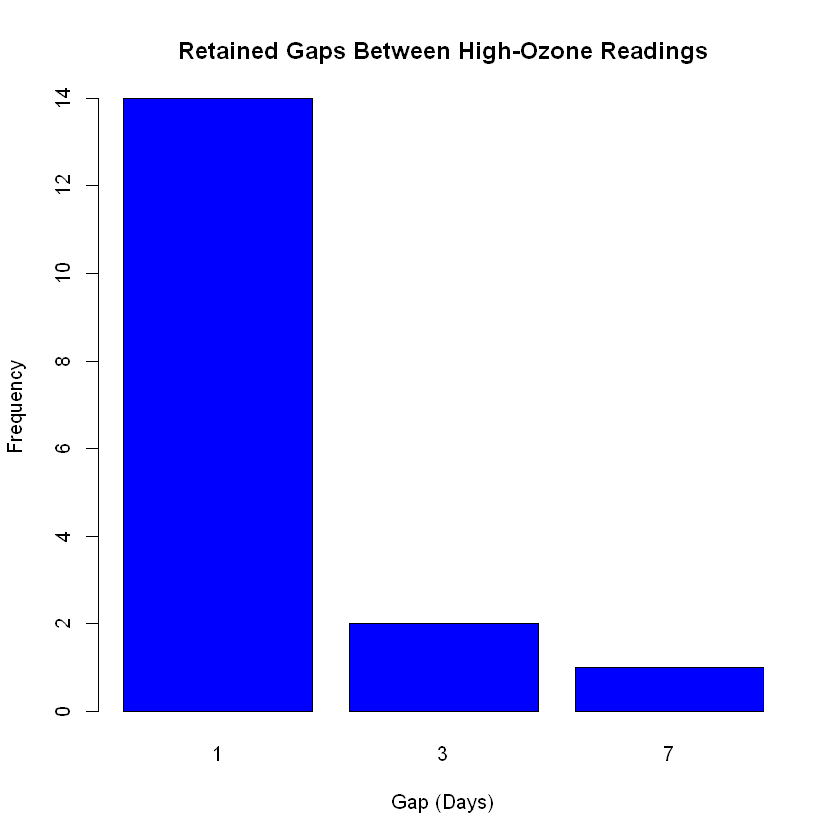

In [63]:
#Read the air quality dataset and 
airQuality <- read.csv("data/airquality.csv")
#Look at the first few rows of the air quality dataset
head(airQuality)
#Check the structure and dimension of the air quality dataset
str(airQuality)
dim(airQuality)
#Create calender dates for the air quality observations
airQuality$Date <- as.Date(
    paste(
        1973,
        airQuality$Month,
        airQuality$Day,
        sep = "-"
    )
)
head(
    airQuality[
        ,
        c("Date", "Month", "Day", "Ozone")
    ]
)
#Identify the days with recorded ozone readings of at least 70
highOzoneRows <- which(
    !is.na(airQuality$Ozone) & 
    airQuality$Ozone >= 70
)
highOzoneRows
length(highOzoneRows)
highOzoneDays <- airQuality[
    highOzoneRows,
    c("Date", "Ozone")
]
highOzoneDays
#Calculate gaps between consecutive high ozone dates
candidateGaps <- as.numeric(
    diff(highOzoneDays$Date)
)
candidateGaps
length(candidateGaps)
#Check every candidate gap for missing readings
candidateValidGap <- logical(length(candidateGaps))
for (i in seq_along(candidateGaps)) {
    startRow <- highOzoneRows[i]
    endRow <- highOzoneRows[i + 1]
    intervalOzone <- airQuality$Ozone[startRow:endRow]
    candidateValidGap[i] <- all(!is.na(intervalOzone))
}
candidateValidGap
#Count excluded gaps and keep only the valid ones
countExcluded <- sum(!candidateValidGap)
countExcluded
keepValidGaps <- candidateGaps[candidateValidGap]
keepValidGaps
length(keepValidGaps)
summary(keepValidGaps)
#Create a bar plot the retained gaps
barplot(
    table(keepValidGaps),
    main = "Retained Gaps Between High-Ozone Readings",
    xlab = "Gap (Days)",
    ylab = "Frequency",
    col = "blue"
)
#Create a gap minus one for the geometric model
geometricGaps <- keepValidGaps - 1
geometricGaps
#Calcuate fitted mean gap under the geometric model
meanGeometricGaps <- mean(geometricGaps)
meanGeometricGaps
#Estimate the geometric probability parameter
probGeometric <- 1 / (1 + meanGeometricGaps)
probGeometric
#Calculate fitted mean of the original gap
meanGeometric <- 1 / probGeometric
meanGeometric
#Fit Exponential approximation to retained gaps
lambdaExponential <- 1 / mean(keepValidGaps)
lambdaExponential
#Calculate fitted mean gap under Exponential model
meanExponential <- 1 / lambdaExponential
meanExponential
#Calculate the probability of a gap of at most 2 days for both geometric and exponential
probMost2Geometric <- pgeom(1, prob = probGeometric)
probMost2Exponential <- pexp(2, rate = lambdaExponential)
probMost2Geometric
probMost2Exponential
#Calculate observed proportion
observedProbMost2 <- mean(keepValidGaps <= 2)
observedProbMost2

As shown above, there were 25 recorded ozone readings of at least 70, producing 24 candidate calendar-day gaps between consecutive high-ozone observations. For each candidate gap, I checked whether every day from the first endpoint through the second endpoint had an observed ozone reading. Seven gaps contained at least one missing ozone reading and were therefore excluded, leaving 17 retained gaps. The retained gaps ranged from 1 to 7 days, with a median of 1 day and a mean of approximately 1.588 days. Most retained gaps were one day, revealing that the observed high-ozone readings tended to occur in clusters during periods with complete ozone measurements. For the Geometric model, I modeled the gap minus one, $Y = G - 1$, so that $Y$ has support 0, 1, 2,... The estimated Geometric probability was $\hat{p}\approx 0.6296$, giving a fitted mean gap of approximately 1.588 days. The Exponential approximation had estimated rate $\hat{\lambda}\approx 0.6296$, also giving a fitted mean of approximately 1.588 days. The observed proportion of gaps of at most two days was approximately 0.8235. The fitted Geometric model estimated $P(G \leq 2) \approx 0.8628$, while the Exponential approximation estimated $P(G \leq 2) \approx 0.7161$. Therefore, the Geometric estimate was closer to the observed proportion for short gaps. This is reasonable because calendar-day gaps are discrete positive integers, which corresponds naturally to the Geometric model, whereas the Exponential distribution is continuous and is only an approximation. With that being said, the AIC values for the Geometric and Exponential models should not be directly compared. The Geometric likelihood is based on a discrete probability mass function evaluated at integer-valued gaps, while the Exponential likelihood is based on a continuous probability density. Because these likelihoods use different underlying measures and therefore are not on the same likelihood scale, their AIC values do not provide a valid direct model comparison. Missing ozone readings may affect the analysis because gaps containing missing observations were excluded. A missing day could potentially have contained an ozone reading of at least 70, so retaining such a gap could incorrectly treat two observed high-ozone days as consecutive qualifying events. Excluding these gaps avoids making assumptions about the unobserved ozone values, but it also reduces the sample from 24 candidate gaps to 17 retained gaps and may introduce bias if missingness is not random. Seasonality is also important because high ozone readings may not occur at a constant rate throughout the observation period. Ozone levels can vary across the months represented in the dataset, so the probability of observing a high-ozone day may change over time. The simple Geometric and Exponential models assume a constant event probability or rate, respectively, so strong seasonal variation would violate that assumption. Therefore, these fitted models should be interpreted as simplified descriptions of the retained gaps rather than evidence that high-ozone events occur at a constant rate throughout the season.


**(e)** For the setosa flowers, calculate squared Mahalanobis distances using all four measurements, the sample mean vector, and the sample covariance matrix. Make a QQ plot against a Chi-Squared distribution with 4 degrees of freedom. Report the rows above its 97.5th percentile. Explain what a large distance means and why the Chi-Squared reference is approximate here.


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : chr  "setosa" "setosa" "setosa" "setosa" ...


[1] 150   5

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


[1] 50  5

...

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3434  1.6305  2.9719  3.9200  5.3238 12.3276 

[1] 11.14329

42 44 
42 44

[1] 2

,SetosaRow,OriginalRow,SquaredMahalanobis
,<int>,<int>,<dbl>
42,42,42,12.32764
44,44,44,12.31006


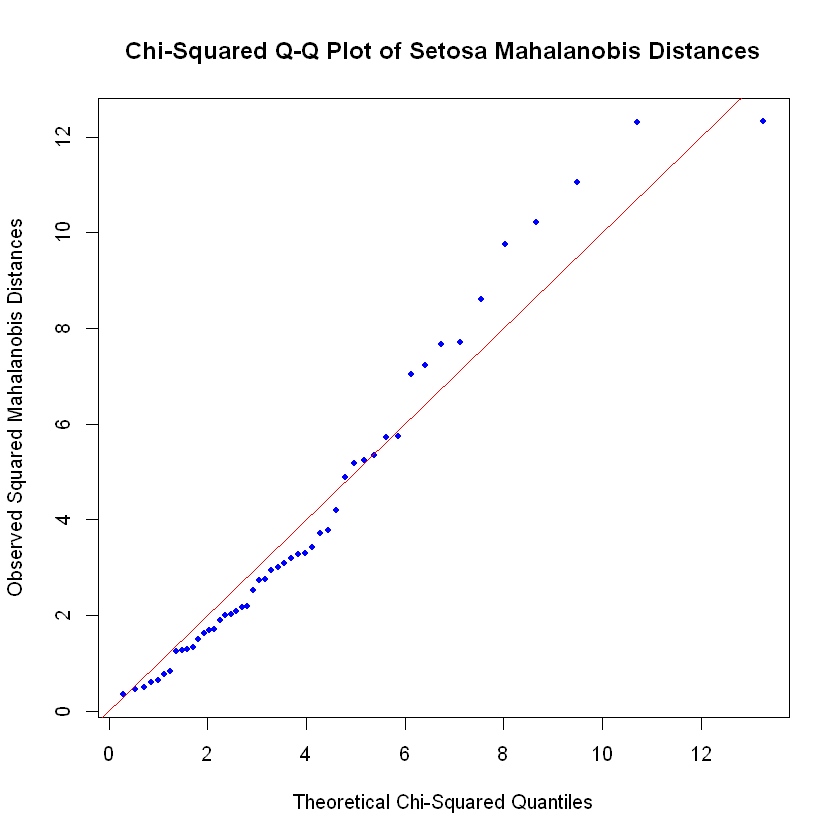

In [ ]:
#Read the iris dataset
irisData <- read.csv("data/iris.csv")
#Check for the rows, structure, and dimensions
head(irisData)
str(irisData)
dim(irisData)
#Keep only the Setosa flowers
setosaFlowers <- irisData[irisData$Species == "setosa",]
head(setosaFlowers)
dim(setosaFlowers)
#Let's extract all 4 measurements
setosaMeasurements <- setosaFlowers[, c("Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width")]
head(setosaMeasurements)
#Calculate the sample mean vector
setosaMeanVector <- colMeans(setosaMeasurements)
setosaMeanVector
#Calculate the sample covariance matrix
setosaCovMatrix <- cov(setosaMeasurements)
#Calculate the squared Mahalanobis distances
squaredMahalanobis <- mahalanobis(setosaMeasurements, center = setosaMeanVector, cov = setosaCovMatrix)
squaredMahalanobis
summary(squaredMahalanobis)
#Calculate the 97.5th percentile of chi-squared distribution with 4 degrees of freedom
chiSquared97.5 <- qchisq(0.975, df = 4)
chiSquared97.5
#Identify Setosa observations above the 97.5th percentile
above97.5 <- which(squaredMahalanobis > chiSquared97.5)
above97.5
length(above97.5)
#Create table of observations above the chi-squared distribution above 97.5th percentile
unusualSetosa <- data.frame(
    SetosaRow = above97.5,
    OriginalRow = as.integer(
        row.names(setosaFlowers)[above97.5]
    ),
    SquaredMahalanobis = squaredMahalanobis[above97.5] 
)
unusualSetosa
#Created chi-squared QQ plot of observed Mahalanobis diatances
numberSetosa <- length(squaredMahalanobis)
probPointsSetosa <- ppoints(numberSetosa)
theoreticalChiSquare <- qchisq(probPointsSetosa, df = 4)
observedMahalanobis <- sort(squaredMahalanobis)
plot(theoreticalChiSquare, observedMahalanobis, main = "Chi-Squared Q-Q Plot of Setosa Mahalanobis Distances", xlab = "Theoretical Chi-Squared Quantiles", ylab = "Observed Squared Mahalanobis Distances", pch = 16, col = "blue", cex = 0.7)
abline(0, 1, col = "red", lwd = 1)

As shown above, the analysis included 50 Setosa flowers and used all four measurements: sepal length, sepal width, petal length, and petal width. The sample mean vector was (5.006, 3.428, 1.462, 0.246). Squared Mahalanobis distances were calculated using this sample mean vector and the sample covariance matrix. The 97.5th percentile of a Chi-Squared distribution with 4 degrees of freedom was approximately 11.1433. 2 Setosa observations exceeded this cutoff. Row 42 had a squared Mahalanobis distance of approximately 12.3276, and row 44 had a squared Mahalanobis distance of approximately 12.3101. These are therefore the observations identified as unusually distant relative to the Chi-Squared reference.
A large squared Mahalanobis distance means that an observation has an unusual combination of the four flower measurements relative to the multivariate center of the Setosa sample. Unlike an ordinary distance, Mahalanobis distance accounts for both the different scales of the variables and their covariance. Therefore, a flower can have a large distance because its overall combination of measurements is unusual even if no single measurement appears extremely unusual by itself.
The Chi-Squared QQ plot provides an approximate diagnostic for whether the squared Mahalanobis distances behave as expected under a multivariate Normal model. The observations show the general increasing pattern expected from the Chi-Squared reference, although there are visible departures from the reference line, particularly toward the larger distances. The $\chi_4^2$ reference is only approximate here because the mean vector and covariance matrix are not known population parameters. They were estimated from the same finite sample of 50 Setosa flowers used to calculate the Mahalanobis distances. Therefore, the resulting squared distances do not follow an exact $\chi_4^2$ distribution. The Chi-Squared distribution is being used as a reference diagnostic rather than as an exact finite-sample distribution.
